# PREDIX HER2 — multimodal pCR prediction: reproducibility notebook

This notebook is the reviewer-facing verification of every number in the revised
manuscript of the PREDIX HER2 multimodal pCR-prediction study. It runs **top to
bottom with no manual steps** from the package root and, at every stage, recomputes
a deposited quantity from the primary artefacts and **asserts equality** with the
deposited tables. All post-processing seeds are fixed, so agreement is exact up
to floating point. The tolerance is 1e-9 on point estimates and
confidence-interval bounds everywhere except two comparisons that run looser
because of how the workbook stores the value, not because the agreement is
weaker: the `Performance` sheet of `PREDIX_HER2_results.xlsx` stores AUROC
rounded to four decimals and is compared at that resolution (Section 5), and the
`internal_AUROC` column of the external-validation workbook is stored to six
decimals and is compared at 1e-6 (Section 11). Both are restated at the point of
use.

**Package layout**

| folder | contents |
|---|---|
| `code/` | the analysis scripts (`multimodal_pcr_pipeline.py`, `cv_estimands.py`, `generate_report.py`, `revision_analyses.py`, `external_validation.py`, `preflight.py`) + `tests/test_statistics.py` + production run scripts |
| `data/` | the canonical PREDIX input file, plus the two external transcriptomic metric files that may be redistributed (I-SPY2, NCT02326974). The TransNEO metrics validated in Section 11 are third-party and are not redistributed, which is why Section 11 reports three cohorts from two deposited external files. |
| `results/` | the production PKL artefacts (model outputs), CV splits, provenance |
| `report/` | the deposited figures and tables that this notebook reproduces |
| `environment/` | requirements + the production and notebook environments |

**Two reproduction levels**

- **Level A — this notebook (≈ 15 min, mostly Sections 5, 7 and 12).** Starting
  from the deposited PKLs in `results/`, every revision table and figure is
  reproduced exactly: all post-modelling randomness (the cluster bootstraps) is
  seeded from one function, `cv_estimands.shared_seed` (base 20240517 with a
  deterministic CRC32 offset per quantity). Section 12 regenerates the *entire*
  deposited report from the PKLs and compares it cell by cell.
- **Level B — full pipeline re-run (many CPU-hours).** Re-run the model pipeline with
  the exact production command (from `code/production_run_ubuntu.sh`, step 1):

  ```bash
  python multimodal_pcr_pipeline.py \
      --data_path clin_multiomics_curated_metrics_PREDIX_HER2_new.txt \
      --results_dir results --splits_dir results/shared_splits \
      --mode elasticnet --training_data cc_only --dedup_per_scenario \
      --experiments global dhp tdm1 \
      --classifiers ElasticNet_LR RandomForest ExtraTrees HistGradBoost SVM_RBF SVM_Linear \
      --repeats_global 200 --repeats_arm 100 \
      --outer_folds_global 5 --outer_folds_arm 5 \
      --inner_folds_global 5 --inner_folds_arm 3 \
      --univariate_screen in_fold --feature_pool curated \
      --n_jobs <cores> --seed 42 --consensus
  ```

  (steps 2–4 of the same script regenerate the report and the external validation).
  The cross-validation partitions are fully determined by seed 42, but the
  classifier-internal randomness of the tree models is **deliberately unseeded**
  (documented design choice — seeding it would correlate the CV repeats and
  artificially narrow the fold-level variance). A Level B re-run therefore reproduces
  the linear-model numbers exactly and the tree-model numbers statistically; the
  deposited PKLs are the archival record, and Level A verifies everything downstream
  of them exactly.

**What this notebook demonstrates, stated precisely.** The **post-modelling
computation** — consensus aggregation, metric computation, the seeded
patient-level cluster bootstrap, signature ranking and fusion summarisation —
reproduces bit-identically from the deposited fold-level outputs, and it does so
across Linux → Windows and a much newer software stack. It does **not** show that
re-fitting the models reproduces bit-identically: classifier-internal randomness is
deliberately unseeded, and `reproducibility_note` in `results/run_provenance.json`
records that the last digit of a per-fold metric may vary. The correct phrasing is
"exactly reproducible from the deposited fold-level outputs", never
"bit-reproducible end to end".

**How to run**: open in Jupyter and *Run All*, or headless:
`python run_notebook.py` (requires `nbformat`, `nbclient`, `ipykernel`).
Software: Python ≥ 3.10 and `pip install -r environment/requirements.txt`.

Every number quoted in the markdown below is read from the deposited workbooks
under `report/tables/`, which are this package's source of record, and every one
of them is recomputed from the primary artefacts and asserted by the code cell
that follows it.

## This repository is the no-patient-data variant

The PREDIX individual-level input matrix, `data/clin_multiomics_curated_metrics_PREDIX_HER2_new.txt`
(197 patients x 112 columns (patientID, pCR and 110 curated metrics); Clin 5 / RNA 42 / DNA 41 / Prot 19 / WSI 3; SHA-256 `64dd2f3ff1c99170c70a27685c7d9d5633c5ae2edb23b45dbabc1b88a575cef0`), **is not deposited here**. See
`data/README.md`.

Four cells announce themselves and stand down here — Section 1's two
input-file hash checks, the whole of Section 2, Section 11's re-run of the two
locked external validations from source, and, in Section 12, the comparison of
the two artefacts Section 11 would have regenerated. One further step inside
Section 12 stands down for the same reason:
`fig_internal_vs_external_by_model_scope` is drawn from the two workbooks
Section 11 did not produce here, so it is exempted from the figure presence
check by name and says so in its output. The other script-drawn figure,
`fig_feature_ranking_by_scope`, reads `results/` alone and regenerates here
exactly as it does in the full deposit. Everything else — every
number computed from `results/`, the full regeneration of the report in
Sections 12a and 12b, the manifest — runs exactly as it always did, and the
final count of passed checks is lower by exactly the checks those cells
contain.

**Which execution the stored outputs below come from:** if they show Section 2
completing, they were produced against the full tree, with the matrix present,
and are kept as the record of that run; re-running `run_notebook.py` in this
repository replaces them with this tree's, in which those cells announce
themselves instead.

Restore the matrix at the path above and every guard falls through: the
notebook is then the notebook of the full deposit, and reproduces the stored
outputs.

`docs/NO_PATIENT_DATA.md` states what individual-level information the
deposited `results/` artefacts still carry. It is not nothing, and it is worth
reading before treating this variant as anonymous.


## How the analysis is run, and what this notebook does instead

**This notebook verifies results; it does not produce them.** Everything it reads
was produced by one production run, driven by `code/production_run_ubuntu.sh`.
The stages below are that script's real order, with the flags it actually
passes.

| # | stage | what it does |
|---|---|---|
| −1 | `preflight.py` | Gates the input file before anything expensive starts: cohort shape, per-modality counts, the candidate funnel, and a hard exit if the outcome-derived `RNA_ADC_trafficking` column is present in either spelling. |
| 0 | `tests/test_statistics.py` | Runs the statistical test suite as a gate. |
| 1 | `multimodal_pcr_pipeline.py` | **The multi-hour step**, and the only one that fits models: 5 outer folds × 200 repeats pooled and 5 × 100 per arm, over six classifier families (elastic-net logistic regression, random forest, extra trees, histogram gradient boosting, linear SVM and RBF SVM — the last competes in model selection but contributes nothing to signature discovery), with `--training_data cc_only --dedup_per_scenario --univariate_screen in_fold --feature_pool curated --seed 42 --consensus`. Writes the fold-level artefacts in `results/`. |
| 2 | `generate_report.py` | Turns those artefacts into the headline figures and tables. |
| 3 | `revision_analyses.py` | Calibration, events per variable, selection stability and the paired model comparisons, all with cluster-bootstrap intervals. |
| 4a | `external_validation.py --export_shared_features_only` | Determines which transcriptomic features exist in both PREDIX and each external cohort. |
| 4b | `multimodal_pcr_pipeline.py` (×2) | The **arm-matched** RNA-only locked-model runs, one per cohort. |
| 4c | `external_validation.py --locked_ispy2 --locked_nct` | Applies those locked models once to each external cohort. |

Stage 1 is the only expensive one: the model-fitting stage runs for hours, and
everything after it runs in minutes. **This notebook takes about 15 minutes**,
because it re-processes stored fold-level outputs rather than refitting
anything. Per-stage wall-clock times were not recorded for this run and are
therefore not quoted; the run's own timestamp is printed by Section 1 straight
from `results/run_provenance.json`.

That difference is exactly the scope limit on the reproducibility claim, and it
belongs here rather than in a footnote. What is demonstrated is that the
**post-modelling computation** — consensus aggregation, metric computation, the
seeded patient-level cluster bootstrap, signature ranking and fusion
summarisation — is **exactly reproducible from the deposited fold-level
outputs**, and reproduces across a change of operating system and a much newer
software stack. What is *not* demonstrated is that refitting the models would
reproduce them bit for bit: classifier-internal randomness is deliberately left
unseeded, and the pipeline's own `reproducibility_note` records that the last
digit of a per-fold metric may vary between runs. The deposited artefacts in
`results/` are the archival record, and this notebook verifies everything
downstream of them.

### How features reach a model

This is worth stating once, in order, because the order is what the
multiplicity and overfitting arguments are computed against.

Redundancy is removed **before any split**, in two outcome-blind steps: the fixed
`TIER1_REMOVE` list (21 names, 18 present in this delivery, leaving 92
candidates), and then a per-scenario, within-modality deduplication on each
scenario's own complete-case cohort (`--dedup_per_scenario`,
`code/feature_deduplication.py`: |r| ≥ 0.80 for continuous features, exact
agreement ≥ 0.80 for segment-called copy number, Cohen's κ ≥ 0.80 for binary
indicators), which removes 11 (pooled), 12 (DHP) and 6 (T-DM1) more, so 81, 80
and 86 candidates enter the fold loop. Every removal, its retained counterpart
and the statistic behind it are in
`results/<scenario>/<scenario>_deduplication_audit.csv`. There is **no in-fold
correlation filter**: `CORR_FILTER_MODS` is empty, so no modality has one, and
the two outcome-blind steps above are the only redundancy steps that run.

What does run inside every outer fold, fitted on training patients only, is a
near-zero-variance filter followed by an **in-fold univariate outcome screen**: a
tie-corrected Mann–Whitney U test of each candidate against pCR, with
Benjamini–Hochberg control at q ≤ 0.25, capped at 40 features and floored at 5.
Modalities with six or fewer features (clinical and WSI) skip the screen
entirely, since screening them would be meaningless.

**That floor is not decorative, and the honest disclosure is that it frequently
overrode the FDR gate.** Across the 5,999 folds with a screen record it fired in
**2,041**. The flag the pipeline records, `floor_used`, is set when *fewer than
five* features reached q ≤ 0.25 — not when none did — so what those 2,041 folds
have in common is that the floor rather than the FDR gate decided how many
features entered the model; the record does not distinguish a fold in which four
features passed from one in which none did. The rate is strongly
modality-dependent: DHP DNA 448/500 (89.6%), T-DM1 DNA 394/499 (79.0%) and pooled
DNA 652/1,000 (65.2%) at the top, then T-DM1 RNA 187/500 (37.4%), DHP proteomics
173/500 (34.6%), T-DM1 proteomics 155/500 (31.0%), DHP RNA 28/500 (5.6%), pooled
RNA 3/1,000 (0.3%) and pooled proteomics 1/1,000 (0.1%). In the folds where it
fired the screen is selecting the five best-ranked features rather than a set
that passed a significance threshold, and any reading of the genomic results, in
every scenario, should carry that. Clinical and WSI never enter this count: with five and three features they
skip the screen entirely.

Finally, probabilities are **unconditionally** Platt-recalibrated within the
cross-validation — verified applied in 10,000 of 10,000 scenario × modality ×
fold combinations — not recalibrated only when an inner-loop slope strays outside
some window.

In [1]:
# ── Setup: imports, paths, helpers ──────────────────────────────────────────
import os, sys, json, time, zlib, pickle, hashlib, subprocess, warnings
# NOTE on the subprocess calls below: every one of them passes
# encoding="utf-8". Without it, subprocess.run(text=True) decodes the
# child's stdout with the platform's ANSI codepage, which on Windows turns
# the en-dashes in the scripts' own CI strings (0.652-0.839) into mojibake
# in this notebook's embedded output. The analysis scripts print UTF-8.
from pathlib import Path
T_NOTEBOOK_START = time.time()

PKG = Path.cwd()
assert (PKG / "code").is_dir() and (PKG / "results").is_dir(), (
    "Run this notebook from the package root (the folder containing code/, "
    "data/, results/ and report/).")
sys.path.insert(0, str(PKG / "code"))

warnings.filterwarnings("ignore")            # silence sklearn FutureWarnings etc.
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")                        # before importing the analysis modules
import openpyxl
import pymupdf
from IPython.display import Image, display

import cv_estimands as CE                    # the ONE estimand definition (shared module)
import revision_analyses as RA               # revision statistics (CIs, calibration, DeLong, ...)
import generate_report as GR                 # report generator (imported to prove importability)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)

# The bootstrap seed rule lives in exactly ONE place — cv_estimands.shared_seed
# — and this notebook calls it rather than keeping a private copy. The offset
# spans the full crc32 range instead of `crc32(tag) % 10000`, because the
# modulus collides for 3 pairs among the ~126 tags these scripts generate, and
# two analyses silently sharing a resample stream is invisible in the output. A
# stale copy here would move every CI endpoint in the third decimal while
# leaving the point estimates untouched, which is why Section 1 asserts that
# this notebook is calling the shared function.
BOOT_SEED  = CE.DEFAULT_BOOT_SEED            # 20240517, the seed base
N_BOOT     = CE.DEFAULT_N_BOOT               # 2000 bootstrap resamples
SCENARIOS  = ["Global", "DHP", "T-DM1"]
EXP_MAP    = {"Global": "global", "DHP": "dhp", "T-DM1": "tdm1"}
UNIMODALS  = ["Clin", "RNA", "DNA", "Prot", "WSI"]
FUSED      = "Fused_ElasticNet"
ALL_MODELS = UNIMODALS + [FUSED]

CHECKS = []   # (section, name, passed, detail)

def check(section, name, cond, detail=""):
    cond = bool(cond)
    CHECKS.append((section, name, cond, detail))
    print(f"  [{'PASS' if cond else 'FAIL'}] {name}" + (f"  ({detail})" if detail else ""))
    if not cond:
        # Deliberately NOT `assert`: python -O strips assert statements, which
        # would turn every check in this notebook into a no-op that still prints
        # PASS. The failure path has to be unconditional.
        raise AssertionError(
            f"CHECK FAILED: section {section} / {name} {detail}")
    return cond

def seed_for(tag):
    # THE definition, imported rather than reimplemented: revision_analyses.py
    # and generate_report.py call this same function, so the same cell prints
    # the same CI everywhere.  = BOOT_SEED + crc32(tag) % 2**31
    return CE.shared_seed(tag)

def read_sheet(path, sheet, first_header):
    # Read one styled worksheet written by the analysis scripts. Explanatory
    # note rows precede the header; the header row is the first row whose
    # first cell equals `first_header`.
    ws = openpyxl.load_workbook(path, data_only=True)[sheet]
    rows = [[c.value for c in r] for r in ws.iter_rows()]
    hdr_i = next(i for i, r in enumerate(rows) if r and r[0] == first_header)
    hdr = [h for h in rows[hdr_i] if h is not None]
    body = [list(r[:len(hdr)]) + [None] * (len(hdr) - len(r))
            for r in rows[hdr_i + 1:] if any(v is not None for v in r)]
    return pd.DataFrame(body, columns=hdr)

def relpath(p):
    # EVERY path this notebook prints goes through here. Printing absolute paths
    # would bake the author's filesystem — and the name of the delivery folder —
    # into the executed outputs that ship inside the deposit.
    p = Path(p)
    try:
        return p.resolve().relative_to(PKG.resolve()).as_posix()
    except ValueError:
        return p.name

def show_pdf(path, page=0, dpi=110):
    # Render one page of a deposited PDF inline (pymupdf -> PNG).
    doc = pymupdf.open(path)
    png = doc[page].get_pixmap(dpi=dpi).tobytes("png")
    doc.close()
    print(f"[deposited figure] {relpath(path)}")
    display(Image(data=png))

def close_to(a, b, tol=1e-9):
    if a is None or b is None:
        return a is None and b is None
    a, b = float(a), float(b)
    if np.isnan(a) and np.isnan(b):
        return True
    return abs(a - b) <= tol

# ---- NO-PATIENT-DATA VARIANT (inserted by build_github_repo.py) ----
# This is the variant of the deposit published WITHOUT the PREDIX
# individual-level input matrix. The cells that need it announce themselves
# and are skipped; everything computed from results/ runs unchanged. Restore
# the file at the path below and every guard falls through, reproducing the
# stored outputs.
PREDIX_INPUT = PKG / "data" / "clin_multiomics_curated_metrics_PREDIX_HER2_new.txt"
NO_PATIENT_DATA = not PREDIX_INPUT.exists()

def no_data_skip(section, what, n_checks):
    print("-" * 78)
    print(f"[NO PATIENT DATA] Section {section} SKIPPED - {what}.")
    print(f"  needs  : data/clin_multiomics_curated_metrics_PREDIX_HER2_new.txt")
    print(f"           197 patients x 112 columns (patientID, pCR and 110 curated metrics)")
    print(f"           Clin 5 / RNA 42 / DNA 41 / Prot 19 / WSI 3; SHA-256 64dd2f3ff1c99170c70a27685c7d9d5633c5ae2edb23b45dbabc1b88a575cef0")
    print(f"  effect : {n_checks} verification check(s) in this section are not run;")
    print(f"           the notebook's own PASS total at the end is lower by that many.")
    print( "  see    : data/README.md            - what runs without the file, and")
    print( "                                       how to request it")
    print( "           docs/NO_PATIENT_DATA.md   - what individual-level information")
    print( "                                       the deposited results/ still carry")
    print("-" * 78)

if NO_PATIENT_DATA:
    print("\n*** NO-PATIENT-DATA VARIANT: data/clin_multiomics_curated_metrics_PREDIX_HER2_new.txt is not in this repository. ***")
# ---- end NO-PATIENT-DATA VARIANT ----
print("Package root: .  (every path printed by this notebook is relative to it)")
print("Setup complete.")


*** NO-PATIENT-DATA VARIANT: data/clin_multiomics_curated_metrics_PREDIX_HER2_new.txt is not in this repository. ***
Package root: .  (every path printed by this notebook is relative to it)
Setup complete.


## 1. Environment and provenance

**What this step does.** It prints the library versions this notebook is running
on, recomputes the SHA-256 digest of the input data file, and compares that
digest with the one the production pipeline recorded when it trained the models.
It then prints the production run's configuration and the canonical
cross-validation statement the pipeline generated.

**Why it exists.** A reproducibility package is worth nothing unless the data
inside it is provably the data the models were trained on. The pipeline writes
the digest of its input into `run_provenance.json` at training time, so this
comparison is the one claim in the package that cannot be satisfied by editing
prose. The cross-validation statement is printed rather than retyped because
every description of the CV design in the manuscript is copied from that file;
generating it from the parameters that actually ran is what stops the Methods
text and the code from drifting apart.

**Reads** `data/clin_multiomics_curated_metrics_PREDIX_HER2_new.txt`,
`results/run_provenance.json` and `results/methods_cv_statement.txt`.
**Writes** nothing.

**What to look for.** The recomputed and recorded digests must be identical and
must both begin `64dd2f3f`. The parameter block should read
`training_data: cc_only`, `univariate_screen: in_fold`,
`signature_source: winner_folds`, `corr_threshold: 0.9`, `repeats_global: 200`,
`repeats_arm: 100`, `seed: 42`.

**If it fails.** A digest mismatch means the deposit is internally inconsistent —
the data file and the model artefacts do not belong to the same run — and
nothing later in the notebook can be trusted. A difference in the printed
library versions is **not** a failure and is expected: the production run used
the pinned versions in `environment/requirements.txt`, and this notebook is
normally executed on a newer stack.

In [2]:
print("=" * 78); print("SECTION 1 — Environment and provenance"); print("=" * 78)
import sklearn, scipy
print(f"Python       : {sys.version.split()[0]}  ({sys.platform})")
for m in (np, pd, sklearn, scipy, matplotlib, openpyxl):
    print(f"{m.__name__:13s}: {m.__version__}")

DATA_FILE = PKG / "data" / "clin_multiomics_curated_metrics_PREDIX_HER2_new.txt"
prov = json.loads((PKG / "results" / "run_provenance.json").read_text(encoding="utf-8-sig"))
# ---- NO-PATIENT-DATA VARIANT (inserted by build_github_repo.py) ----
if NO_PATIENT_DATA:
    no_data_skip("1", "the input-file SHA-256 verification", 2)
    print("Provenance SHA-256 :", prov["input_data"]["sha256"],
          "(the file it fingerprints is not deposited here, so this notebook "
          "cannot confirm it; the value is stated in data/README.md)")
else:
    sha = hashlib.sha256(DATA_FILE.read_bytes()).hexdigest()
    print("\nInput file SHA-256 :", sha)
    print("Provenance SHA-256 :", prov["input_data"]["sha256"])
    check("1", "input-file SHA-256 matches results/run_provenance.json",
          sha == prov["input_data"]["sha256"])
    check("1", "SHA-256 equals the published value (64dd2f3f...cef0)",
          sha == "64dd2f3ff1c99170c70a27685c7d9d5633c5ae2edb23b45dbabc1b88a575cef0")
# ---- end NO-PATIENT-DATA VARIANT ----

print("\n--- production run provenance (results/run_provenance.json) ---")
print(f"pipeline_version : {prov['pipeline_version']}")
print(f"generated_utc    : {prov['generated_utc']}")
print(f"random_seed      : {prov['random_seed']}")
p = prov["parameters"]
for k in ["experiments", "training_data", "repeats_global", "repeats_arm",
          "outer_folds_global", "outer_folds_arm", "inner_folds_global",
          "inner_folds_arm", "univariate_screen", "univ_fdr_q", "univ_max_k",
          "univ_min_k", "feature_pool", "signature_source",
          "stability_thresh_global", "stability_thresh_arm",
          "corr_threshold", "consensus"]:
    print(f"  {k:24s}: {p[k]}")
print("environment of the production model run:")
for k, v in prov["environment"].items():
    print(f"  {k:13s}: {v}")
print("\nreproducibility_note:")
print(" ", prov["reproducibility_note"])
check("1", "the notebook uses the analysis scripts' own bootstrap seed rule "
           "(cv_estimands.shared_seed), not a copy of it",
      seed_for("Global|consensus|RNA|AUROC")
      == CE.shared_seed("Global|consensus|RNA|AUROC", base=CE.DEFAULT_BOOT_SEED)
      and RA.BOOT_SEED == CE.DEFAULT_BOOT_SEED
      and RA.N_BOOT == CE.DEFAULT_N_BOOT,
      f"seed base {CE.DEFAULT_BOOT_SEED}, {CE.DEFAULT_N_BOOT} resamples")

print("\n--- results/methods_cv_statement.txt ---")
print((PKG / "results" / "methods_cv_statement.txt").read_text(encoding="utf-8-sig"))

SECTION 1 — Environment and provenance
Python       : 3.14.7  (win32)
numpy        : 2.5.2
pandas       : 3.0.5
sklearn      : 1.9.0
scipy        : 1.18.0
matplotlib   : 3.11.1
openpyxl     : 3.1.5
------------------------------------------------------------------------------
[NO PATIENT DATA] Section 1 SKIPPED - the input-file SHA-256 verification.
  needs  : data/clin_multiomics_curated_metrics_PREDIX_HER2_new.txt
           197 patients x 112 columns (patientID, pCR and 110 curated metrics)
           Clin 5 / RNA 42 / DNA 41 / Prot 19 / WSI 3; SHA-256 64dd2f3ff1c99170c70a27685c7d9d5633c5ae2edb23b45dbabc1b88a575cef0
  effect : 2 verification check(s) in this section are not run;
           the notebook's own PASS total at the end is lower by that many.
  see    : data/README.md            - what runs without the file, and
                                       how to request it
           docs/NO_PATIENT_DATA.md   - what individual-level information
                                 

## 2. The canonical dataset

**What this step does.** It opens the one input file the entire analysis rests
on and reconstructs, from the file itself, the two patient cohorts the study
uses and the feature panel the models draw on.

**Why it exists.** Two objections turn on this section. The first is which
patients each model saw: every comparison in Sections 5 and 7 is paired only if
every model saw the same patients, so the cohort is derived here from the data
rather than asserted. The second is the size of the candidate pool, because the
feature panel is what the multiplicity and overfitting arguments are computed
against.

The file holds **197 patients × 112 columns** (`patientID`, `pCR`, and 110
curated features prefixed `Clin_` / `RNA_` / `DNA_` / `Prot_` / `WSI_`), and it
supports two different cohorts that must not be confused.

The **evaluation cohort** is the 110 patients complete across RNA, DNA,
proteomics and WSI. Clinical covariates are recorded for everyone and imputed
within each fold, so `Clin_` does not enter the completeness rule (see
`get_complete_case()` in `code/multimodal_pcr_pipeline.py`). Every model,
unimodal or fused, is scored on exactly these 110 patients — 46 pCR events, DHP
59 with 24 events and T-DM1 51 with 22 — and that is what keeps every comparison
in Sections 5 and 7 paired.

There is no wider training cohort. Under `--training_data cc_only` every model,
unimodal or fused, is **trained as well as scored on those same 110 patients**,
so within any outer fold the five unimodal models and the fusion layer see an
identical set of training patients and an identical set of events. Section 9
reads that back off the deposited per-fold table: a median of 88 training
patients and 37 events per pooled fold, 47 and 19 in DHP, 41 and 18 in T-DM1 —
the same in every modality. The other 87 patients in the delivered file carry
some assays but not all four molecular ones; they describe the delivery and
enter neither training nor scoring. Fusion still happens at the level of
predictions rather than features — each modality is modelled independently and
only the second-stage combiner sees all five — but that is a choice about
interpretability and about what can be locked and re-applied to an external
cohort, not about cohort size.

On the feature panel: redundancy is removed **once, before any split**, by the
fixed outcome-blind `TIER1_REMOVE` list. That list names 21 features, of which
18 are present in this delivery, leaving **92 candidates**; the per-scenario
deduplication (`--dedup_per_scenario`) then removes 11 (pooled), 12 (DHP) and 6
(T-DM1) of them on each scenario's own complete-case cohort before it is split,
so 81, 80 and 86 enter the in-fold screen — the audits are
`results/<scenario>/<scenario>_deduplication_audit.csv`. The three the list names
but the file does not carry are `DNA_TMB_uniform`,
`DNA_TMB_clone` and `DNA_pTMB`, so this panel carries clonal oncogenic TMB only
and "total TMB" would be wrong. `RNA_ADC_trafficking` was withdrawn upstream by
the authors before round 2 and is absent from the file altogether; it is not on
the `TIER1_REMOVE` list, and `preflight.py` hard-exits if it ever reappears.
`RNA_FCGR3B` is present in the file and removed by `TIER1_REMOVE`, which is an
outcome-blind decision about measurement validity, not a data-delivery accident.

**Reads** the data file and `code/multimodal_pcr_pipeline.py` (for
`TIER1_REMOVE` and `SIGNATURE_SOURCE`). **Writes** nothing.

**What to look for.** Shape 197 × 112; evaluation cohort 110 with 46 events, DHP
59/24 and T-DM1 51/22; per-modality coverage in the delivered file Clin 197 /
RNA 185 / DNA 189 / Prot 137 / WSI 169, which describes the delivery and not any
training set; 87 patients outside the complete-case cohort; and 110 metrics with
21 listed, 18 present and 92 candidates.

**If it fails.** A wrong cohort count means the deposited data file is not the
one this analysis was run on. A wrong candidate count means `code/` and the data
file disagree about the feature panel. Neither is an environment problem; both
mean the package is inconsistent and should not be used.

One trap, stated once because it has cost real time: `Clin_TUMSIZE` and
`Clin_prolifvalu` encode missing values as the **string** `"Unknown"` rather than
as `NaN`. Both encode to `NaN` and are median-imputed per fold, so modelling is
unaffected — but the tokens are non-null strings, so `dropna()` cannot see them.
The cell below prints both halves of the trap next to each other: **110** rows
carry no `NaN` in any of the 110 feature columns, and **7** cells nevertheless
hold the string `"Unknown"`. A `dropna()` over every feature column therefore
keeps rows the pipeline treats as partly missing, and returns a number that
looks right for the wrong reason. Use the RNA/DNA/Prot/WSI rule, as this section
does.

In [3]:
print("=" * 78); print("SECTION 2 — The canonical dataset"); print("=" * 78)
# ---- NO-PATIENT-DATA VARIANT (inserted by build_github_repo.py) ----
if NO_PATIENT_DATA:
    no_data_skip('2', "the canonical-dataset section: the input file's SHA-256, its 197x112 shape, the Clin 5 / RNA 42 / DNA 41 / Prot 19 / WSI 3 panel count, and the derivation of the n=110 complete-case evaluation cohort", 16)
else:
    first_line = DATA_FILE.open(encoding="utf-8").readline()
    check("2", "file is tab-separated (delimiter check)", first_line.count("\t") == 111,
          f"{first_line.count(chr(9))} tabs in the header line")
    df = pd.read_csv(DATA_FILE, sep="\t")
    print(f"shape: {df.shape[0]} patients x {df.shape[1]} columns")
    check("2", "197 patients x 112 columns", df.shape == (197, 112))

    mod_cols = {m: [c for c in df.columns if c.startswith(m + "_")] for m in UNIMODALS}
    other = [c for c in df.columns if not any(c.startswith(m + "_") for m in UNIMODALS)]
    for m in UNIMODALS:
        print(f"  {m:5s}: {len(mod_cols[m]):3d} feature columns")
    print(f"  other: {other}")
    check("2", "features per modality = Clin 5 / RNA 42 / DNA 41 / Prot 19 / WSI 3",
          [len(mod_cols[m]) for m in UNIMODALS] == [5, 42, 41, 19, 3])
    check("2", "identifier and outcome columns are patientID and pCR",
          other == ["patientID", "pCR"])

    # ── The EVALUATION cohort: the pipeline's completeness rule ──────────────────
    # Complete RNA, DNA, proteomics and WSI. Clin_ does NOT enter the definition
    # (get_complete_case() in code/multimodal_pcr_pipeline.py): clinical covariates
    # are recorded for everyone and imputed in-fold. Every model is SCORED here.
    molecular = [c for m in ("RNA", "DNA", "Prot", "WSI") for c in mod_cols[m]]
    cc = df.dropna(subset=molecular)
    arm = df["Clin_Arm"].map({"DHP": 0, "T-DM1": 1})     # the pipeline's encoding
    cc_arm = arm.loc[cc.index]
    n_dhp,  ev_dhp  = int((cc_arm == 0).sum()), int(cc.loc[cc_arm == 0, "pCR"].sum())
    n_tdm1, ev_tdm1 = int((cc_arm == 1).sum()), int(cc.loc[cc_arm == 1, "pCR"].sum())
    print(f"\nevaluation cohort (complete case): n={len(cc)}, "
          f"pCR events={int(cc['pCR'].sum())}")
    print(f"  DHP   (Clin_Arm=0): n={n_dhp}, events={ev_dhp}")
    print(f"  T-DM1 (Clin_Arm=1): n={n_tdm1}, events={ev_tdm1}")
    check("2", "complete case n=110 with 46 pCR events",
          (len(cc), int(cc["pCR"].sum())) == (110, 46))
    check("2", "DHP arm (code 0) n=59 / 24 events — confirms DHP=0 coding",
          (n_dhp, ev_dhp) == (59, 24))
    check("2", "T-DM1 arm (code 1) n=51 / 22 events", (n_tdm1, ev_tdm1) == (51, 22))
    check("2", "the evaluation cohort has no missing molecular values",
          int(cc[molecular].isna().sum().sum()) == 0)

    # ── Modality coverage in the delivered file ─────────────────────────────────
    # These are the patients who carry each assay. Every model TRAINS on the 110
    # complete cases; these counts describe the delivery, not the training sets.
    print("\nper-modality coverage in the delivered file:")
    train_counts = {}
    for m in UNIMODALS:
        sub_m = df.dropna(subset=mod_cols[m])
        train_counts[m] = (len(sub_m), int(sub_m["pCR"].sum()))
        print(f"  {m:5s}: n={len(sub_m):3d}, events={int(sub_m['pCR'].sum()):3d}")
    check("2", "modality coverage = Clin 197/88, RNA 185/84, DNA 189/84, "
               "Prot 137/61, WSI 169/71",
          train_counts == {"Clin": (197, 88), "RNA": (185, 84), "DNA": (189, 84),
                           "Prot": (137, 61), "WSI": (169, 71)})
    check("2", "87 patients carry at least one assay but sit outside the "
               "complete-case cohort", len(df) - len(cc) == 87)
    print(f"\nmissing molecular cells in the full delivery: "
          f"{int(df[molecular].isna().sum().sum())}")

    # ── The 'Unknown' token trap, stated once ────────────────────────────────────
    n_literal = len(df.dropna(
        subset=[c for c in df.columns if c not in ("patientID", "pCR")]))
    n_unknown = int((df[["Clin_TUMSIZE", "Clin_prolifvalu"]]
                     .astype(str) == "Unknown").sum().sum())
    print(f"rows with no NaN in ANY of the 110 feature columns: {n_literal}")
    print(f'cells carrying the string "Unknown" in Clin_TUMSIZE/Clin_prolifvalu: '
          f"{n_unknown}  (encoded to NaN and median-imputed per fold)")
    check("2", 'Clin_TUMSIZE / Clin_prolifvalu carry "Unknown" string tokens, so a '
               "naive dropna() over all features is NOT the pipeline's cohort rule",
          n_unknown > 0)

    # ── What the locked external-validation models are actually refit on ─────────
    # The locked transcriptomic models used in Section 11 are ARM-MATCHED: each is
    # refit once on its own arm's complete cases (DHP 59/24, T-DM1 51/22) and
    # applied once. No model is fitted on an RNA-complete cohort and there is no
    # pooled locked model, so check the training sizes the external workbook
    # RECORDS against the arm cohorts derived above from the data file. That is what
    # makes the label on this check load-bearing: a mislabelled refit population
    # would fail here instead of passing on an unrelated true fact.
    _ev_chk = read_sheet(PKG / "report/tables/revision/external_validation.xlsx",
                         "External_validation", "cohort")
    _arm_cc = {"DHP": (n_dhp, ev_dhp), "T-DM1": (n_tdm1, ev_tdm1)}
    _refit_ok = len(_ev_chk) > 0 and all(
        (int(_r["n_PREDIX_train"]), int(_r["events_PREDIX_train"]))
        == _arm_cc.get(str(_r["cohort_resembles_PREDIX_arm"]).strip())
        for _, _r in _ev_chk.iterrows())
    print(f"\nlocked external models are refit on the ARM complete cases: "
          f"DHP n={n_dhp}/{ev_dhp} events, T-DM1 n={n_tdm1}/{ev_tdm1} events")
    check("2", "every locked external model is refit on its own arm's complete "
               "cases (DHP 59/24, T-DM1 51/22), matching what "
               "external_validation.xlsx records as its training population",
          _refit_ok, f"{len(_ev_chk)} deposited external rows checked")

    # ── The curated panel and the outcome-blind deduplication list ───────────────
    import multimodal_pcr_pipeline as MP
    feat = [c for c in df.columns if c not in ("patientID", "pCR")]
    t1_present = [c for c in MP.TIER1_REMOVE if c in df.columns]
    print(f"\ncurated panel: {len(feat)} metrics; TIER1_REMOVE lists "
          f"{len(MP.TIER1_REMOVE)}, {len(t1_present)} present "
          f"-> {len(feat) - len(t1_present)} candidates enter the in-fold screen")
    check("2", "110-metric panel; TIER1_REMOVE 21 listed / 18 present -> 92 candidates",
          (len(feat), len(MP.TIER1_REMOVE), len(t1_present),
           len(feat) - len(t1_present)) == (110, 21, 18, 92))
    check("2", "the locked signature is aggregated over the winner folds "
               "(SIGNATURE_SOURCE == 'winner_folds')",
          MP.SIGNATURE_SOURCE == "winner_folds")

    # RNA_ADC_trafficking was withdrawn upstream by the authors (it is NOT on the
    # TIER1_REMOVE list); DNA_TMB_clone is on the list but is also absent from the
    # file. Both must stay absent: the first is outcome-derived, the second is an
    # exact duplicate of the retained DNA_TMB_clone_oncogenic.
    for _absent in ("RNA_ADC_trafficking", "DNA_TMB_clone"):
        check("2", f"{_absent} is absent from this delivery",
              _absent not in df.columns)
    check("2", "RNA_FCGR3B is present in the file and removed by TIER1_REMOVE "
               "(an outcome-blind decision), not by the data delivery",
          "RNA_FCGR3B" in df.columns and "RNA_FCGR3B" in MP.TIER1_REMOVE)
# ---- end NO-PATIENT-DATA VARIANT ----


SECTION 2 — The canonical dataset
------------------------------------------------------------------------------
[NO PATIENT DATA] Section 2 SKIPPED - the canonical-dataset section: the input file's SHA-256, its 197x112 shape, the Clin 5 / RNA 42 / DNA 41 / Prot 19 / WSI 3 panel count, and the derivation of the n=110 complete-case evaluation cohort.
  needs  : data/clin_multiomics_curated_metrics_PREDIX_HER2_new.txt
           197 patients x 112 columns (patientID, pCR and 110 curated metrics)
           Clin 5 / RNA 42 / DNA 41 / Prot 19 / WSI 3; SHA-256 64dd2f3ff1c99170c70a27685c7d9d5633c5ae2edb23b45dbabc1b88a575cef0
  effect : 16 verification check(s) in this section are not run;
           the notebook's own PASS total at the end is lower by that many.
  see    : data/README.md            - what runs without the file, and
                                       how to request it
           docs/NO_PATIENT_DATA.md   - what individual-level information
                                

## 3. Statistical test suite

**What this step does.** It runs `code/tests/test_statistics.py` as a
subprocess and requires a clean exit.

**Why it exists.** Several statistics in this analysis are implemented directly
against numpy and scipy rather than taken from a statistics package —
DeLong's test, the logistic and Cox fits, the likelihood-ratio test, the
log-rank test, Benjamini–Hochberg adjustment, Wilson intervals and the
Kaplan–Meier estimator. That keeps the deposit installable from a bare
environment, but it means each one has to be validated against an independent
reference, which is what this suite does: scipy, scikit-learn and R's `p.adjust`
where a reference exists, and hand-computed values where one does not. The suite
also checks the type-I error of the DeLong and interaction tests under a true
null, and constructs the held-out-outcome artefact of Section 6 synthetically so
that the estimand argument rests on a reproducible demonstration rather than on
one run's numbers.

**Reads** `code/tests/test_statistics.py` and the modules it imports.
**Writes** nothing.

**What to look for.** Exit code 0 and the line `ALL CHECKS PASSED`.

**If it fails.** This is the one section where a failure most likely points at
your environment rather than at the deposit: a scipy or scikit-learn version
whose defaults have moved can change a reference value. Read the printed
tail — it names the individual check — before concluding that the analysis is
wrong.

In [4]:
print("=" * 78); print("SECTION 3 — Statistical test suite"); print("=" * 78)
t0 = time.time()
r = subprocess.run([sys.executable, str(Path("code") / "tests" / "test_statistics.py")],
                   capture_output=True, text=True,
                   encoding="utf-8", errors="replace", cwd=str(PKG))
# Keep this stdout under a name of its own. `r` is rebound by later cells (the
# pandas iteration in Sections 5 and 7, and the two subprocesses in Section 12),
# and Section 6 asserts on what this suite actually printed.
TEST_SUITE_STDOUT = r.stdout
print(f"exit code {r.returncode} after {time.time()-t0:.0f}s; last 15 lines of output:\n")
print("\n".join(r.stdout.strip().splitlines()[-15:]))
if r.returncode != 0:
    print("\nSTDERR (tail):\n", r.stderr[-3000:])
check("3", "test suite exit code 0", r.returncode == 0)
check("3", "'ALL CHECKS PASSED' printed", "ALL CHECKS PASSED" in r.stdout)

SECTION 3 — Statistical test suite


exit code 0 after 13s; last 15 lines of output:

PASS  brier == mean per-repeat Brier  
PASS  ECE small  0.0228
PASS  overconfident -> slope < 0.75 and CI excludes 1  0.480
PASS  reliability rows cover all (repeat, patient) predictions  
PASS  distinct patients per bin <= n  
PASS  bins ordered by predicted risk  
PASS  observed inside its cluster CI in every bin  
PASS  calibrated: observed ~ predicted per bin  max gap 0.051

=== 15j. legacy mean-of-fold metric ===
PASS  mean_fold_metric == mean sklearn per fold  0.559097
PASS  mean-fold and per-repeat estimands differ in general  

ALL CHECKS PASSED
  [PASS] test suite exit code 0
  [PASS] 'ALL CHECKS PASSED' printed


True

## 4. Deposited model artefacts and the cross-validation design

**What this step does.** It loads the deposited fold-level artefacts and
reconstructs the cross-validation design from them, rather than taking the
design on trust from the configuration printed in Section 1.

**Why it exists.** Every interval in this package is computed by resampling
patients across cross-validation repeats, and that is only valid if each repeat
really does contain exactly one out-of-fold prediction per patient. This section
proves that property directly from the stored predictions: 5 folds in every
repeat, no incomplete repeats, and every patient predicted exactly once per
repeat, for all 18 scenario × model combinations. It is the foundation the
estimand in Section 5 stands on, so it is checked before any number is reported.

For each scenario the pipeline deposited two artefacts. The **discovery** file
holds the fully nested run, in which the feature signature and the classifier
were selected inside each outer training fold. The **consensus** file holds the
re-evaluation in which the frozen consensus signature was refit on the same
splits. Both are carried because they answer different questions, and both are
verified here.

**Reads** `results/{global,dhp,tdm1}/*_elasticnet_results.pkl` and
`*_consensus_eval.pkl`. **Writes** nothing.

**What to look for.** 1,000 outer folds pooled (5 × 200) and 500 per arm
(5 × 100); `incomplete_repeats` zero everywhere; `preds_per_patient` equal to the
repeat count in every row; cohorts 110 / 59 / 51 with 46 / 24 / 22 events.

**If it fails.** A missing or short repeat means the deposited artefacts are
truncated, and the bootstrap intervals computed from them would be quietly
wrong. This is a deposit-integrity failure, not an environment one.

In [5]:
print("=" * 78); print("SECTION 4 — PKLs and CV design"); print("=" * 78)
DISC, CONS = {}, {}
for sc in SCENARIOS:
    exp = EXP_MAP[sc]
    with open(PKG / "results" / exp / f"{exp}_elasticnet_results.pkl", "rb") as f:
        DISC[sc] = pickle.load(f)
    with open(PKG / "results" / exp / f"{exp}_consensus_eval.pkl", "rb") as f:
        CONS[sc] = pickle.load(f)

EXPECT = {"Global": dict(folds=1000, repeats=200, n=110, ev=46),
          "DHP":    dict(folds=500,  repeats=100, n=59,  ev=24),
          "T-DM1":  dict(folds=500,  repeats=100, n=51,  ev=22)}

RM, rows = {}, []
for sc in SCENARIOS:
    e = EXPECT[sc]
    n_cons_folds = len(CONS[sc]["folds"])
    for mod in ALL_MODELS:
        n_disc = len(DISC[sc].get(mod, []))
        rm_c = CE.consensus_repeat_matrix(CONS[sc], mod)
        rm_d = CE.discovery_repeat_matrix(DISC[sc][mod])
        RM[(sc, "consensus", mod)] = rm_c
        RM[(sc, "discovery", mod)] = rm_d
        ppp = rm_c.predictions_per_patient()
        rows.append(dict(scenario=sc, model=mod, discovery_folds=n_disc,
                         consensus_folds=n_cons_folds,
                         n_repeats=rm_c.n_repeats,
                         folds_per_repeat=sorted(set(rm_c.folds_per_repeat)),
                         incomplete_repeats=rm_c.incomplete_repeats,
                         n_patients=rm_c.n_patients, n_events=rm_c.n_events,
                         preds_per_patient=f"{ppp.min()}-{ppp.max()}"))
        assert n_disc == e["folds"] and n_cons_folds == e["folds"]
        assert rm_c.n_repeats == e["repeats"] and rm_d.n_repeats == e["repeats"]
        assert set(rm_c.folds_per_repeat) == {5} and set(rm_d.folds_per_repeat) == {5}
        assert rm_c.incomplete_repeats == 0 and rm_d.incomplete_repeats == 0
        assert (ppp == rm_c.n_repeats).all()
        assert (rm_d.predictions_per_patient() == rm_d.n_repeats).all()
        assert (rm_c.n_patients, rm_c.n_events) == (e["n"], e["ev"])
        assert (rm_d.n_patients, rm_d.n_events) == (e["n"], e["ev"])
display(pd.DataFrame(rows))
check("4", "design verified for all 18 (scenario, model) pairs: 5 folds/repeat, "
           "200/100/100 complete repeats, every patient predicted exactly once "
           "per repeat, cohorts 110/59/51 with 46/24/22 events", True)

SECTION 4 — PKLs and CV design


,scenario,model,discovery_folds,consensus_folds,n_repeats,folds_per_repeat,incomplete_repeats,n_patients,n_events,preds_per_patient
0,Global,Clin,1000,1000,200,[5],0,110,46,200-200
1,Global,RNA,1000,1000,200,[5],0,110,46,200-200
2,Global,DNA,1000,1000,200,[5],0,110,46,200-200
3,Global,Prot,1000,1000,200,[5],0,110,46,200-200
4,Global,WSI,1000,1000,200,[5],0,110,46,200-200
5,Global,Fused_ElasticNet,1000,1000,200,[5],0,110,46,200-200
6,DHP,Clin,500,500,100,[5],0,59,24,100-100
7,DHP,RNA,500,500,100,[5],0,59,24,100-100
8,DHP,DNA,500,500,100,[5],0,59,24,100-100
9,DHP,Prot,500,500,100,[5],0,59,24,100-100


  [PASS] design verified for all 18 (scenario, model) pairs: 5 folds/repeat, 200/100/100 complete repeats, every patient predicted exactly once per repeat, cohorts 110/59/51 with 46/24/22 events


True

## 5. Headline performance

**What this step does.** It recomputes every headline discrimination and
calibration number — AUROC, AUPRC and Brier score with 95% confidence
intervals — from the deposited predictions, for all three scenarios, both
artefact sources and all six models, and asserts each against the deposited
tables.

**Why it exists.** The original submission reported a "±" that was the standard
deviation of per-fold AUROC, which is not a confidence interval and is not a
measure of uncertainty about the reported estimate. This section replaces it
with an interval that respects the structure of the design, and recomputes it
independently of the workbook so the two have to agree.

**The estimand, stated in full.** Within each cross-validation repeat every
patient has exactly one out-of-fold prediction; the metric is computed on that
complete out-of-fold vector, and the reported value is the mean over the repeats
(200 pooled, 100 per arm). The 95% interval is a patient-level **cluster**
bootstrap: 2,000 stratified resamples of *patients*, with a resampled patient
carrying all of its repeat predictions. Predictions are never averaged across
repeats or across models — Section 6 explains why that matters. Each quantity
draws its seed from a single function, `cv_estimands.shared_seed`, so the same
cell reproduces the same interval wherever it is computed.

**Reads** the deposited PKLs and
`report/tables/revision/revision_performance_CI.xlsx`, plus the `Performance`
sheet of `report/tables/PREDIX_HER2_results.xlsx`. **Writes** nothing.

**What to look for.** 360 recomputed values agreeing with the workbook to 1e-9,
and the headline pooled table: fused 0.792 (0.718–0.857) with RNA the strongest
single modality at 0.813 — that is, RNA sits **above** the fused model, not
below it, and the pooled fused model ranks second of six. Section 7 tests
whether that 0.020 difference is distinguishable at all. The second check in
this section is one of the two deliberate departures from the 1e-9 rule: the
`Performance` sheet of `PREDIX_HER2_results.xlsx` stores AUROC rounded to four
decimals, so the recomputed value is rounded to four decimals before it is
compared.

**If it fails.** Point estimates that match while interval bounds differ almost
always mean the seed rule has drifted between the notebook and the analysis
scripts, not that the analysis is wrong. It is a silent failure mode — every
number stays plausible — which is why the rule lives in one function,
`cv_estimands.shared_seed`, and why Section 1 asserts that this notebook calls
it rather than a copy of it. Point estimates that differ mean the deposited
artefacts and the deposited tables do not correspond.

In [6]:
print("=" * 78); print("SECTION 5 — Headline performance with cluster-bootstrap CIs"); print("=" * 78)
print("Recomputing AUROC/AUPRC/Brier + 95% CI for 36 (scenario, source, model) cells,")
print(f"{N_BOOT} patient-level cluster-bootstrap resamples each ...")
t0 = time.time()
perf_rows = []
for sc in SCENARIOS:
    for source in ("consensus", "discovery"):
        for mod in ALL_MODELS:
            rm = RM[(sc, source, mod)]
            row = dict(scenario=sc, source=source, model=mod,
                       n_patients=rm.n_patients, n_events=rm.n_events,
                       n_cv_repeats=rm.n_repeats)
            for metric in ("AUROC", "AUPRC", "Brier"):
                res = CE.bootstrap_repeat_metric_ci(
                    rm.P, rm.y, metric, n_boot=N_BOOT,
                    seed=seed_for(f"{sc}|{source}|{mod}|{metric}"))
                row[metric] = res["estimate"]
                row[f"{metric}_CI_low"] = res["ci_low"]
                row[f"{metric}_CI_high"] = res["ci_high"]
            if source == "consensus":
                getter = ((lambda f: f["fused_y_pred"]) if mod == FUSED
                          else (lambda f, m=mod: f["unimodal_y_pred"][m]))
                row["AUROC_mean_per_fold"] = CE.mean_fold_metric(CONS[sc]["folds"], getter, "AUROC")
            else:
                row["AUROC_mean_per_fold"] = CE.mean_fold_metric(
                    DISC[sc][mod], lambda f: f["y_pred"], "AUROC")
            perf_rows.append(row)
PERF = pd.DataFrame(perf_rows)
print(f"done in {(time.time()-t0)/60:.1f} min\n")

hp = PERF[PERF.source == "consensus"].copy()
hp["AUROC (95% CI)"] = hp.apply(
    lambda r: f"{r.AUROC:.3f} ({r.AUROC_CI_low:.3f}-{r.AUROC_CI_high:.3f})", axis=1)
print("Headline table — consensus models, AUROC (95% patient-cluster-bootstrap CI):")
display(hp.pivot(index="model", columns="scenario",
                 values="AUROC (95% CI)").reindex(ALL_MODELS)[SCENARIOS])
print("\nFull recomputed table (both sources; AUPRC / Brier / continuity column included):")
display(PERF.round(4))

SECTION 5 — Headline performance with cluster-bootstrap CIs
Recomputing AUROC/AUPRC/Brier + 95% CI for 36 (scenario, source, model) cells,
2000 patient-level cluster-bootstrap resamples each ...


done in 1.8 min

Headline table — consensus models, AUROC (95% patient-cluster-bootstrap CI):


scenario,Global,DHP,T-DM1
model,,,
Clin,0.606 (0.514-0.703),0.522 (0.411-0.621),0.702 (0.562-0.835)
RNA,0.813 (0.727-0.883),0.808 (0.704-0.900),0.788 (0.655-0.900)
DNA,0.594 (0.520-0.666),0.730 (0.611-0.838),0.734 (0.589-0.862)
Prot,0.726 (0.642-0.808),0.825 (0.712-0.918),0.672 (0.540-0.793)
WSI,0.598 (0.505-0.688),0.621 (0.507-0.731),0.428 (0.397-0.459)
Fused_ElasticNet,0.792 (0.718-0.857),0.827 (0.730-0.912),0.791 (0.688-0.876)



Full recomputed table (both sources; AUPRC / Brier / continuity column included):


,scenario,source,model,n_patients,n_events,n_cv_repeats,AUROC,AUROC_CI_low,AUROC_CI_high,AUPRC,AUPRC_CI_low,AUPRC_CI_high,Brier,Brier_CI_low,Brier_CI_high,AUROC_mean_per_fold
0,Global,consensus,Clin,110,46,200,0.6062,0.5143,0.7028,0.5174,0.4439,0.6334,0.2289,0.2040,0.2540,0.6298
1,Global,consensus,RNA,110,46,200,0.8127,0.7269,0.8830,0.7315,0.6298,0.8469,0.1740,0.1404,0.2115,0.8286
2,Global,consensus,DNA,110,46,200,0.5941,0.5205,0.6660,0.5107,0.4621,0.5993,0.2395,0.2259,0.2541,0.6121
3,Global,consensus,Prot,110,46,200,0.7259,0.6424,0.8078,0.6111,0.5395,0.7173,0.2113,0.1859,0.2383,0.7384
4,Global,consensus,WSI,110,46,200,0.5981,0.5050,0.6876,0.5448,0.4717,0.6540,0.2374,0.2219,0.2537,0.6121
5,Global,consensus,Fused_ElasticNet,110,46,200,0.7925,0.7176,0.8568,0.7167,0.6386,0.8131,0.1887,0.1672,0.2127,0.8154
6,Global,discovery,Clin,110,46,200,0.5943,0.5076,0.6794,0.5166,0.4545,0.6166,0.2389,0.2150,0.2606,0.6124
7,Global,discovery,RNA,110,46,200,0.7572,0.6728,0.8341,0.6712,0.5827,0.7823,0.2006,0.1661,0.2402,0.7725
8,Global,discovery,DNA,110,46,200,0.5927,0.5175,0.6686,0.5047,0.4556,0.5882,0.2449,0.2248,0.2647,0.6103
9,Global,discovery,Prot,110,46,200,0.6716,0.5849,0.7553,0.5512,0.4878,0.6563,0.2290,0.2008,0.2588,0.6818


  [PASS] revision_performance_CI.xlsx reproduced (360 values, tol 1e-9)
  [PASS] PREDIX_HER2_results.xlsx Performance sheet: consensus AUROC agrees to 4 decimals (18 cells)
[deposited figure] report/figures/fig01_consensus_performance.pdf


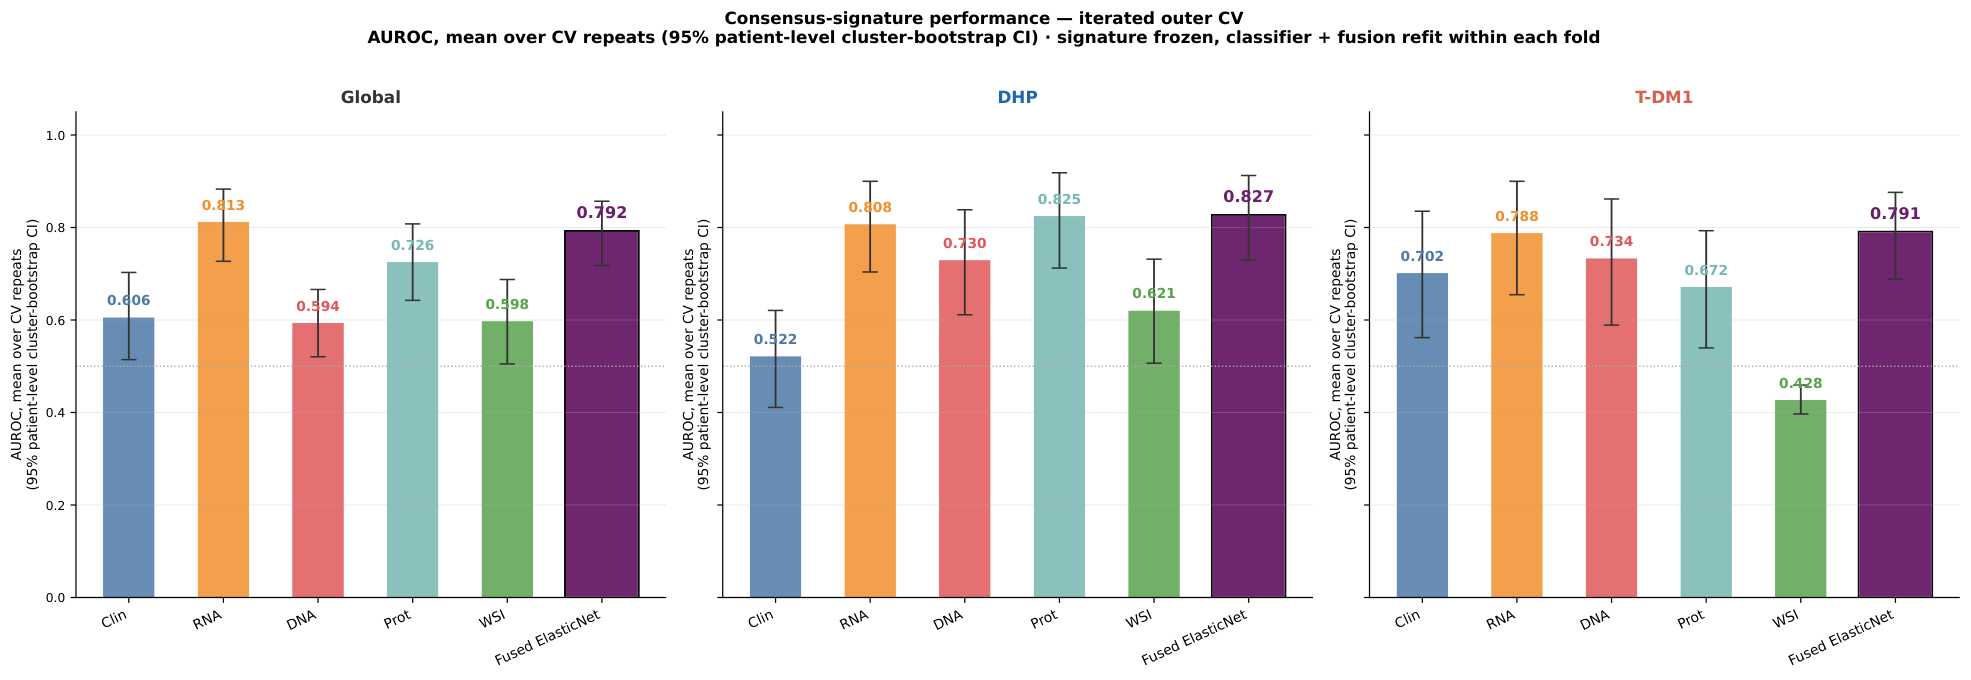

In [7]:
# ── Assert equality with the deposited workbooks ────────────────────────────
wb_perf = read_sheet(PKG / "report/tables/revision/revision_performance_CI.xlsx",
                     "Performance_patient_CI", "scenario").set_index(
                     ["scenario", "source", "model"])
num_cols = ["AUROC", "AUROC_CI_low", "AUROC_CI_high",
            "AUPRC", "AUPRC_CI_low", "AUPRC_CI_high",
            "Brier", "Brier_CI_low", "Brier_CI_high"]
n_cmp = n_bad = 0
for _, r in PERF.iterrows():
    w = wb_perf.loc[(r.scenario, r.source, r.model)]
    for c in num_cols:
        n_cmp += 1
        if not close_to(r[c], w[c]):
            n_bad += 1
            print(f"MISMATCH {r.scenario}/{r.source}/{r.model} {c}: {r[c]!r} vs {w[c]!r}")
    n_cmp += 1
    if not close_to(r["AUROC_mean_per_fold"],
                    w["AUROC_mean_per_fold_(original_estimand,_no_CI)"]):
        n_bad += 1
        print(f"MISMATCH continuity column {r.scenario}/{r.source}/{r.model}")
    assert (int(w["n_patients"]), int(w["n_events"]), int(w["n_cv_repeats"])) == \
           (r.n_patients, r.n_events, r.n_cv_repeats)
check("5", f"revision_performance_CI.xlsx reproduced ({n_cmp} values, tol 1e-9)", n_bad == 0)

wb_main = read_sheet(PKG / "report/tables/PREDIX_HER2_results.xlsx",
                     "Performance", "Scenario").set_index(["Scenario", "Model"])
n_bad = 0
for _, r in PERF[PERF.source == "consensus"].iterrows():
    v = wb_main.loc[(r.scenario, r.model), "AUROC (mean over CV repeats)"]
    if not close_to(round(float(r["AUROC"]), 4), float(v), tol=1e-12):
        n_bad += 1
        print("MISMATCH", r.scenario, r.model, r["AUROC"], v)
check("5", "PREDIX_HER2_results.xlsx Performance sheet: consensus AUROC agrees "
           "to 4 decimals (18 cells)", n_bad == 0)

show_pdf(PKG / "report/figures/fig01_consensus_performance.pdf")

## 6. Why this estimand

**What this step does.** It computes three different summaries of the *same*
out-of-fold predictions for the pooled clinical and fused models, and prints
them side by side: **(a)** the per-repeat AUROC averaged over repeats, which is
the estimand used everywhere in this package; **(b)** the AUROC of each patient's
mean probability across repeats; and **(c)** the mean of per-fold AUROCs, which
was the original submission's estimand.

**Why it exists.** This section exists because of a specific methodological
defect, and it is worth naming rather than burying. Averaging a patient's
out-of-fold probabilities across repeats and then scoring the averaged vector
does not score the model that was fitted — it scores an ensemble of 200 models
that was never fitted, never reported, and could not be deployed. It is also not
a conservative shortcut in either direction. For a model carrying real signal it
is mildly optimistic, because averaging across repeats bags away fit noise. For a
near-uninformative model it can be severely pessimistic: the fold holding out a
pCR patient trained on one fewer event, so that patient's prediction sits a
fraction lower in every repeat, and averaging strips the noise while leaving the
systematic shift intact.

That second failure mode is not hypothetical, and it is present in this run's
own artefacts. The pooled clinical model gives **(a) 0.606 but (b) 0.416** —
computed from exactly the predictions Section 5 scores at 0.606, on the same 110
patients, with a median of 37 pCR events per pooled fold. The pooled fused model
moves the other way, (a) 0.792 against (b) 0.820, which is the bagging
direction. The code cell therefore **prints the realised direction of (b) − (a)
rather than asserting it**. Either direction is a reason not to use (b): the
artefact is a property of the fitted model, not of the data set, so a model in
which it happens to be absent is not evidence that the ensemble summary is safe.
The reproducible demonstration lives in the test suite, which constructs the
artefact synthetically and asserts both its presence under (b) and its absence
under (a); this section checks that those two assertions actually ran.

Summary (c) is close to (a) up to between-fold calibration heterogeneity. The
objection to it was never the point estimate; it was that the "±" reported
beside it was a between-fold standard deviation presented as a confidence
interval.

**Reads** the pooled consensus artefacts. **Writes** nothing.

**What to look for.** That (a) and (b) genuinely differ — if they did not, the
choice of estimand would be cosmetic and this section would have no point — and
the printed direction of (b) − (a).

**If it fails.** Two things are asserted here: that (a) and (b) differ by more
than 0.002, and that the test suite's synthetic reproduction of the artefact ran
and passed in Section 3. A failure of the first would mean these artefacts do
not illustrate the problem, not that the problem is absent — the test suite is
the load-bearing demonstration, which is why the second assertion reads the
suite's own output rather than its source file.

In [8]:
print("=" * 78); print("SECTION 6 — Estimand comparison on the production artefacts"); print("=" * 78)
from sklearn.metrics import roc_auc_score
_seen = {}
for mod in ("Clin", FUSED):
    rm = RM[("Global", "consensus", mod)]
    a = CE.repeat_mean_metric(rm.P, rm.y, "AUROC")
    b = roc_auc_score(rm.y, np.nanmean(rm.P, axis=0))
    getter = ((lambda f: f["fused_y_pred"]) if mod == FUSED
              else (lambda f: f["unimodal_y_pred"]["Clin"]))
    c = CE.mean_fold_metric(CONS["Global"]["folds"], getter, "AUROC")
    print(f"\nGlobal consensus {mod}:")
    print(f"  (a) per-repeat AUROC averaged over 200 repeats (THE estimand) : {a:.4f}")
    print(f"  (b) AUROC of each patient's mean probability (ensemble; NOT used): {b:.4f}")
    print(f"  (c) mean of per-fold AUROC (submission's estimand, no CI)     : {c:.4f}")
    _seen[mod] = (a, b, c)

# The three summaries must genuinely differ, otherwise the choice between them
# would be cosmetic and the correction pointless.
_max_gap = max(abs(b - a) for a, b, _ in _seen.values())
check("6", "the ensemble summary (b) and the per-repeat estimand (a) differ, so the "
           "choice of estimand is consequential",
      _max_gap > 0.002, f"largest |a - b| = {_max_gap:.4f}")

# Direction, reported rather than asserted. Whichever way it falls, (b) is not
# the quantity we report: it scores an R-model ensemble, not the model itself.
_a, _b, _ = _seen["Clin"]
_af, _bf, _ = _seen[FUSED]
_label = lambda d: ("ensemble optimistic (bagging)" if d > 0
                    else "ensemble pessimistic (held-out-outcome shift)")
print(f"\nClinical model: (b) - (a) = {_b - _a:+.4f}  [{_label(_b - _a)}]")
print(f"Fused model   : (b) - (a) = {_bf - _af:+.4f}  [{_label(_bf - _af)}]")
if (_b - _a) * (_bf - _af) < 0:
    print("The two models move in OPPOSITE directions on the same patients and the")
    print("same folds. That is the argument: (b) is not a conservative shortcut,")
    print("and the sign of its bias cannot be known before it is computed.")
else:
    print("Both models happen to move the same way here. That is a property of")
    print("this pair of models, not a guarantee, and (b) still scores an ensemble")
    print("of 200 models that was never fitted and could not be deployed.")

# The synthetic demonstration is only load-bearing if it RAN. Assert on what the
# suite printed in Section 3, not on the presence of a word in its source file:
# a source grep would still pass if the test itself were deleted and only a
# comment survived. These are the two assertion names in section 15d of
# code/tests/test_statistics.py, and the suite prints "PASS  <name>".
_A1 = "per-repeat AUROC of an uninformative model stays near 0.5"
_A2 = "averaging probabilities across repeats first collapses AUROC"
check("6", "the test suite's synthetic held-out-outcome artefact actually ran "
           "and passed in Section 3 (both named assertions found in its output)",
      f"PASS  {_A1}" in TEST_SUITE_STDOUT and f"PASS  {_A2}" in TEST_SUITE_STDOUT,
      "asserted on the captured stdout, not on the test source")

SECTION 6 — Estimand comparison on the production artefacts



Global consensus Clin:
  (a) per-repeat AUROC averaged over 200 repeats (THE estimand) : 0.6062
  (b) AUROC of each patient's mean probability (ensemble; NOT used): 0.4158
  (c) mean of per-fold AUROC (submission's estimand, no CI)     : 0.6298



Global consensus Fused_ElasticNet:
  (a) per-repeat AUROC averaged over 200 repeats (THE estimand) : 0.7925
  (b) AUROC of each patient's mean probability (ensemble; NOT used): 0.8203
  (c) mean of per-fold AUROC (submission's estimand, no CI)     : 0.8154
  [PASS] the ensemble summary (b) and the per-repeat estimand (a) differ, so the choice of estimand is consequential  (largest |a - b| = 0.1905)

Clinical model: (b) - (a) = -0.1905  [ensemble pessimistic (held-out-outcome shift)]
Fused model   : (b) - (a) = +0.0278  [ensemble optimistic (bagging)]
The two models move in OPPOSITE directions on the same patients and the
same folds. That is the argument: (b) is not a conservative shortcut,
and the sign of its bias cannot be known before it is computed.
  [PASS] the test suite's synthetic held-out-outcome artefact actually ran and passed in Section 3 (both named assertions found in its output)  (asserted on the captured stdout, not on the test source)


True

## 7. Paired model comparisons

**What this step does.** It compares the fused model against each single-modality
model, in every scenario and for both artefact sources, and recomputes the
difference in AUROC with a paired interval, a bootstrap p-value, a descriptive
DeLong summary and a verdict.

**Why it exists.** The central claim of a multimodal paper is that integration
buys something. Testing that claim requires a *paired* comparison, because every
model is scored on the same patients in the same repeats, and an unpaired
comparison would discard exactly the correlation that makes the test sensitive.
The primary test here is therefore a paired patient-level cluster bootstrap: the
same patient resample is applied to both models and all repeats. DeLong's test is
computed once per repeat and summarised, but it is reported as descriptive only,
because a test designed for a single ROC curve does not account for the repeated
cross-validation structure.

**On multiplicity.** Benjamini–Hochberg is applied across the family that is
actually published — all 15 comparisons within an artefact source, being three
scenarios times five comparators — not within each scenario separately.
Correcting inside each scenario would ship six independent families of five while
presenting thirty comparisons. Widening the family only ever makes q larger, and
the workbook records both: `q_bootstrap_BH` for the published family and
`q_within_call_BH_m5` for the narrower alternative.

Of the 15 consensus comparisons, 8 are nominally significant at p < 0.05 and
**seven survive** BH at q < 0.05. The one that does not is the pooled fused model
against transcriptomics: Δ = −0.020, p = 0.041, q = 0.077. Its paired interval
excludes zero, so the `verdict` column — which is read off the interval, before
multiplicity — records `RNA higher`, but after correction across the published
family that is **not an established difference**. The verdict column and
`q_bootstrap_BH` sit side by side in the table below and have to be read
together.

**Reads** the deposited PKLs and
`report/tables/revision/revision_model_comparisons.xlsx`. **Writes** nothing.

**What to look for.** The verdict column, and specifically that the fused model
does **not exceed** the best single modality in any scenario — in the pooled
cohort it sits nominally below the transcriptomic model, a difference that does
not survive the multiplicity correction — while being higher than the weaker
modalities. The best single modality is not the same
one in each scenario, which is itself part of the finding. Any interval that
includes zero is reported as "not distinguishable" rather than as a negative
result.

**If it fails.** A mismatch in q while the deltas and p-values agree points at
the multiplicity family, not at the comparison. A mismatch in the deltas means
the artefacts and the workbook disagree.

In [9]:
print("=" * 78); print("SECTION 7 — Paired comparisons"); print("=" * 78)
t0 = time.time()
cmp_rows = []
for sc in SCENARIOS:
    for source in ("consensus", "discovery"):
        rm_f = RM[(sc, source, FUSED)]
        for mod in ALL_MODELS:      # paired comparisons require identical patients
            assert np.array_equal(RM[(sc, source, mod)].pids, rm_f.pids), \
                f"{sc}/{source}/{mod}: patient sets differ"
        seed = seed_for(f"cmp|{sc}|{source}")
        for mod in UNIMODALS:
            P_alt = RM[(sc, source, mod)].P
            bs = CE.paired_bootstrap_repeat_delta(rm_f.P, P_alt, rm_f.y, "AUROC",
                                                  n_boot=N_BOOT, seed=seed)
            dl = CE.per_repeat_test_summary(rm_f.P, P_alt, rm_f.y, RA.delong_test)
            crosses = (not np.isfinite(bs["ci_low"])
                       or (bs["ci_low"] <= 0 <= bs["ci_high"]))
            verdict = ("not distinguishable" if crosses
                       else (f"{FUSED} higher" if bs["delta"] > 0 else f"{mod} higher"))
            cmp_rows.append(dict(scenario=sc, source=source, comparator=mod,
                                 AUROC_fused=bs["estimate_1"],
                                 AUROC_comparator=bs["estimate_2"],
                                 delta=bs["delta"], ci_low=bs["ci_low"],
                                 ci_high=bs["ci_high"], p_bootstrap=bs["p_value"],
                                 DeLong_p_median=dl["p_median"],
                                 DeLong_frac_below_05=dl["frac_p_below_0.05"],
                                 verdict=verdict))
CMP = pd.DataFrame(cmp_rows)

# ── BH across the family that is actually PUBLISHED ─────────────────────────
# The correction is applied within `source`, not within each (scenario, source)
# call. The manuscript makes its fusion-benefit claim per scenario, so a
# reader's implied family is at least the 15 consensus comparisons; correcting
# inside each call would mean m = 5 and would ship six independent families of
# five while presenting 30 comparisons. consensus and discovery are two distinct
# analyses and only the consensus rows carry the headline claim, so m = 15 per
# family. Widening the family only ever makes q LARGER, so this is the
# conservative choice, and revision_analyses.py records the family size it used
# in the workbook for the check below to compare against.
CMP["q_BH"] = np.nan
for _src, _idx in CMP.groupby("source").groups.items():
    _idx = list(_idx)
    CMP.loc[_idx, "q_BH"] = RA.benjamini_hochberg(
        CMP.loc[_idx, "p_bootstrap"].values)
    print(f"  BH family '{_src}': m = {len(_idx)} comparisons")
print(f"done in {(time.time()-t0)/60:.1f} min\n")
display(CMP.round(4))

SECTION 7 — Paired comparisons


  BH family 'consensus': m = 15 comparisons
  BH family 'discovery': m = 15 comparisons
done in 1.4 min



,scenario,source,comparator,AUROC_fused,AUROC_comparator,delta,ci_low,ci_high,p_bootstrap,DeLong_p_median,DeLong_frac_below_05,verdict,q_BH
0,Global,consensus,Clin,0.7925,0.6062,0.1863,0.0888,0.2830,0.0005,0.0018,0.985,Fused_ElasticNet higher,0.0019
1,Global,consensus,RNA,0.7925,0.8127,-0.0202,-0.0395,-0.0010,0.0410,0.3329,0.125,RNA higher,0.0769
2,Global,consensus,DNA,0.7925,0.5941,0.1984,0.1086,0.2818,0.0005,0.0012,0.975,Fused_ElasticNet higher,0.0019
3,Global,consensus,Prot,0.7925,0.7259,0.0666,-0.0000,0.1403,0.0510,0.1457,0.230,not distinguishable,0.0850
4,Global,consensus,WSI,0.7925,0.5981,0.1944,0.0859,0.3041,0.0010,0.0051,0.980,Fused_ElasticNet higher,0.0030
5,Global,discovery,Clin,0.7321,0.5943,0.1378,0.0461,0.2277,0.0030,0.0218,0.655,Fused_ElasticNet higher,0.0075
6,Global,discovery,RNA,0.7321,0.7572,-0.0250,-0.0476,-0.0014,0.0410,0.3642,0.095,RNA higher,0.0769
7,Global,discovery,DNA,0.7321,0.5927,0.1394,0.0634,0.2119,0.0005,0.0163,0.750,Fused_ElasticNet higher,0.0038
8,Global,discovery,Prot,0.7321,0.6716,0.0606,-0.0067,0.1290,0.0830,0.2023,0.190,not distinguishable,0.1383
9,Global,discovery,WSI,0.7321,0.5542,0.1779,0.0694,0.2902,0.0010,0.0107,0.785,Fused_ElasticNet higher,0.0038


  [PASS] revision_model_comparisons.xlsx reproduced (300 values incl. verdicts, tol 1e-9)
  [PASS] BH correction applied over the published family (m = 15 per source: 3 scenarios x 5 comparators), matching BH_family_size  (workbook {15}, recomputed {15})

Key reading (consensus source), read off the table rather than asserted:
  Global: best single modality RNA  0.813 vs fused 0.792 (delta -0.020, p 0.041) -> RNA higher; fused higher than: Clin, DNA, WSI
  DHP   : best single modality Prot 0.825 vs fused 0.827 (delta +0.002, p 0.925) -> not distinguishable; fused higher than: Clin, DNA, WSI
  T-DM1 : best single modality RNA  0.788 vs fused 0.791 (delta +0.003, p 0.944) -> not distinguishable; fused higher than: WSI
Integration MATCHES but does not BEAT the best single modality in any
scenario, and which modality that is depends on the scenario.
[deposited figure] report/figures/revision/revfig07_model_comparisons.pdf


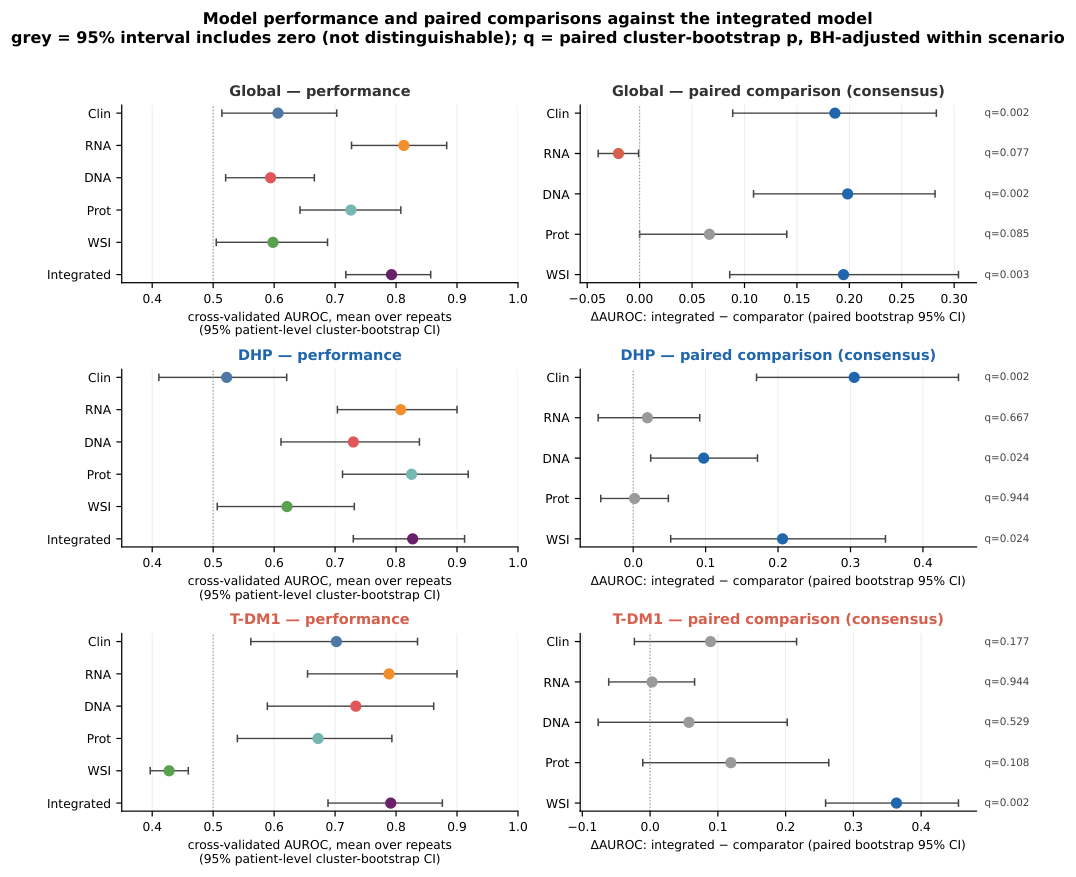

In [10]:
# ── Assert equality with revision_model_comparisons.xlsx ────────────────────
wb_cmp = read_sheet(PKG / "report/tables/revision/revision_model_comparisons.xlsx",
                    "Model_comparisons", "scenario").set_index(
                    ["scenario", "source", "comparator"])
pairs = [("AUROC_fused", "AUROC_reference"), ("AUROC_comparator", "AUROC_comparator"),
         ("delta", "delta_AUROC"), ("ci_low", "delta_CI_low"),
         ("ci_high", "delta_CI_high"), ("p_bootstrap", "p_bootstrap"),
         ("q_BH", "q_bootstrap_BH"), ("DeLong_p_median", "DeLong_p_median_over_repeats"),
         ("DeLong_frac_below_05", "DeLong_frac_repeats_p<0.05")]
n_cmp = n_bad = 0
for _, r in CMP.iterrows():
    w = wb_cmp.loc[(r.scenario, r.source, r.comparator)]
    for mine, dep in pairs:
        n_cmp += 1
        if not close_to(r[mine], w[dep]):
            n_bad += 1
            print(f"MISMATCH {r.scenario}/{r.source}/{r.comparator} {mine}: "
                  f"{r[mine]!r} vs {w[dep]!r}")
    n_cmp += 1
    if r["verdict"] != w["verdict"]:
        n_bad += 1
        print(f"VERDICT MISMATCH {r.scenario}/{r.source}/{r.comparator}: "
              f"{r['verdict']!r} vs {w['verdict']!r}")
check("7", f"revision_model_comparisons.xlsx reproduced ({n_cmp} values incl. "
           f"verdicts, tol 1e-9)", n_bad == 0)

# The workbook records the family size it used; check we used the same one.
_fam = {int(v) for v in wb_cmp["BH_family_size"].dropna().unique()}
_mine = {len(g) for _, g in CMP.groupby("source")}
check("7", "BH correction applied over the published family (m = 15 per "
           "source: 3 scenarios x 5 comparators), matching BH_family_size",
      _fam == _mine == {15}, f"workbook {_fam}, recomputed {_mine}")
print("\nKey reading (consensus source), read off the table rather than asserted:")
_c = CMP[CMP.source == "consensus"]
for _sc in SCENARIOS:
    _s = _c[_c.scenario == _sc]
    _b = _s.loc[_s.AUROC_comparator.idxmax()]
    _hi = sorted(_s[_s.verdict == f"{FUSED} higher"].comparator)
    print(f"  {_sc:6s}: best single modality {_b.comparator:4s} "
          f"{_b.AUROC_comparator:.3f} vs fused {_b.AUROC_fused:.3f} "
          f"(delta {_b.delta:+.3f}, p {_b.p_bootstrap:.3f}) -> {_b.verdict}; "
          f"fused higher than: {', '.join(_hi) if _hi else 'none'}")
print("Integration MATCHES but does not BEAT the best single modality in any")
print("scenario, and which modality that is depends on the scenario.")
show_pdf(PKG / "report/figures/revision/revfig07_model_comparisons.pdf")

## 8. Calibration of the consensus fused model

**What this step does.** It recomputes the calibration of the fused model in each
scenario — the calibration slope, the recalibration intercept, calibration in the
large, the Brier score and the expected calibration error, each with a
cluster-bootstrap interval — and asserts them against the deposited workbook.

**Why it exists.** Discrimination alone does not tell a clinician whether a
predicted probability can be believed. Slope and intercept are fitted on each
repeat's complete out-of-fold vector and averaged over repeats, using the same
patient-level resampling as Section 5 so that the intervals are comparable.
Calibration in the large is reported separately from the recalibration intercept
because they answer different questions: the former fixes the slope at one and
asks whether the average predicted risk matches the observed event rate, while
the latter is the intercept of a full recalibration fit.

**On what the pipeline actually does.** Platt recalibration is applied
**unconditionally** inside the cross-validation, in every fold — 10,000 of 10,000
scenario × modality × fold combinations. It is not applied conditionally on the
inner-loop slope falling outside some window. That matters for reading the
slope: because every fold is recalibrated, a slope above one indicates
probabilities slightly compressed towards the event rate, not a model that is
overconfident.

**Reads** the deposited PKLs and
`report/tables/revision/revision_calibration.xlsx`. **Writes** nothing.

**What to look for.** Whether each calibration slope interval covers 1. The two
arm intervals do — DHP 1.44 (0.88–2.63), T-DM1 1.19 (0.72–2.31) — and the pooled
interval, 1.48 (1.03–2.22), sits just above it. All three point estimates are
**above** 1 — the compressed direction described just above, consistently across
the three scenarios — so where the model errs it errs on the side of caution,
which is the claim the manuscript makes.

**If it fails.** Column-name mismatches here indicate a version skew between the
notebook and `revision_analyses.py`. There are two distinct intercepts stored
under distinct names — `recalibration_intercept*` for the intercept of the full
recalibration fit, `calibration_in_the_large*` for the version with the slope
fixed at one — and reading one under the other's name would compare different
quantities while looking like a value mismatch. Value mismatches mean the
artefacts and the workbook disagree.

SECTION 8 — Calibration


recomputed in 10s



,scenario,n,n_events,slope,slope_lo,slope_hi,intercept,int_lo,int_hi,citl,citl_lo,citl_hi,brier,brier_lo,brier_hi,ece,observed,mean_pred
0,Global,110,46,1.4819,1.0260,2.2154,0.1397,-0.0625,0.4293,0.0038,-0.1177,0.1265,0.1887,0.1664,0.2126,0.1122,0.4182,0.4174
1,DHP,59,24,1.4404,0.8816,2.6258,0.0594,-0.2449,0.5698,-0.0478,-0.2543,0.1719,0.1725,0.1404,0.2090,0.1236,0.4068,0.4159
2,T-DM1,51,22,1.1923,0.7182,2.3115,0.0990,-0.1629,0.7243,0.0390,-0.1745,0.2348,0.1909,0.1569,0.2288,0.1264,0.4314,0.4237


  [PASS] revision_calibration.xlsx Calibration_summary reproduced (45 values, tol 1e-9)
[deposited figure] report/figures/revision/revfig01_calibration.pdf


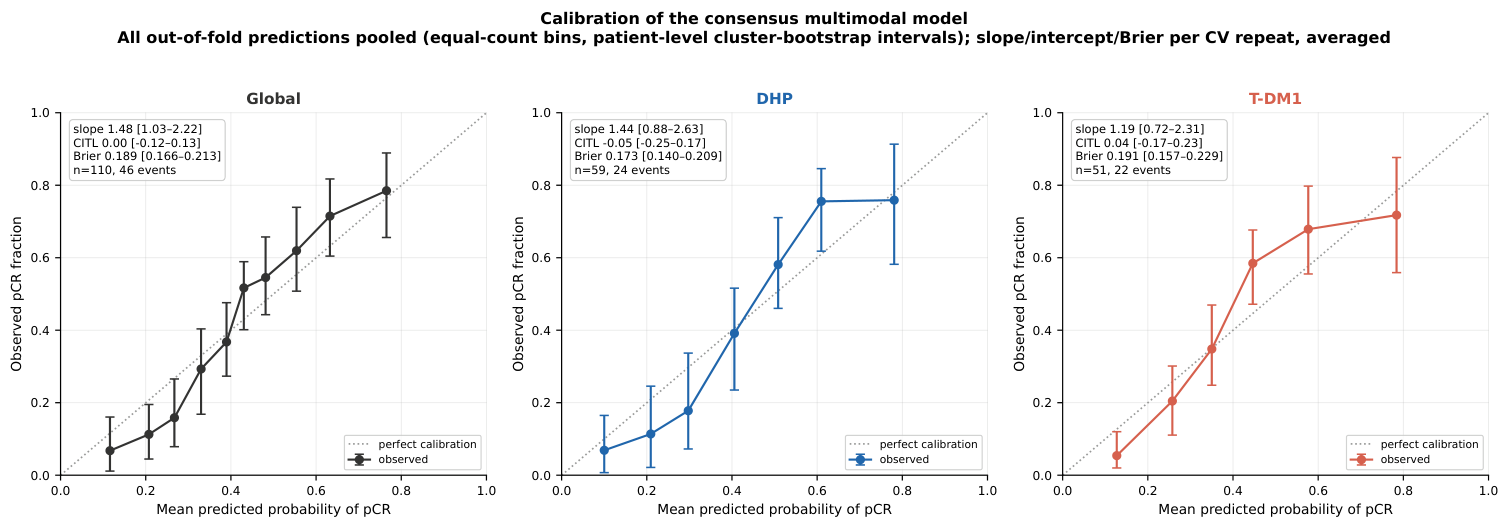

In [11]:
print("=" * 78); print("SECTION 8 — Calibration"); print("=" * 78)
t0 = time.time()
cal_rows = []
for sc in SCENARIOS:
    rm = RM[(sc, "consensus", FUSED)]
    cal = CE.calibration_repeat_summary(rm.P, rm.y, n_boot=N_BOOT,
                                        seed=seed_for(f"cal|{sc}|consensus"),
                                        n_bins=10)
    cal_rows.append(dict(scenario=sc, n=cal["n"], n_events=cal["n_events"],
                         slope=cal["slope"], slope_lo=cal["slope_ci"][0],
                         slope_hi=cal["slope_ci"][1],
                         intercept=cal["intercept"], int_lo=cal["intercept_ci"][0],
                         int_hi=cal["intercept_ci"][1],
                         citl=cal["citl"], citl_lo=cal["citl_ci"][0],
                         citl_hi=cal["citl_ci"][1],
                         brier=cal["brier"], brier_lo=cal["brier_ci"][0],
                         brier_hi=cal["brier_ci"][1], ece=cal["ece"],
                         observed=cal["observed_rate"], mean_pred=cal["mean_predicted"]))
CAL = pd.DataFrame(cal_rows)
print(f"recomputed in {time.time()-t0:.0f}s\n")
display(CAL.round(4))

wb_cal = read_sheet(PKG / "report/tables/revision/revision_calibration.xlsx",
                    "Calibration_summary", "scenario").set_index("scenario")
pairs = [("slope", "calibration_slope"), ("slope_lo", "slope_CI_low"),
         ("slope_hi", "slope_CI_high"),
         # Two DIFFERENT intercepts, stored under two different names: the
         # intercept of the full recalibration fit, and calibration in the large
         # with the slope fixed at 1. Mapping one onto the other would compare
         # different quantities, so the pairing is written out in full.
         ("intercept", "recalibration_intercept"),
         ("int_lo", "recalibration_intercept_CI_low"),
         ("int_hi", "recalibration_intercept_CI_high"),
         ("citl", "calibration_in_the_large"),
         ("citl_lo", "citl_CI_low"), ("citl_hi", "citl_CI_high"),
         ("brier", "brier"), ("brier_lo", "brier_CI_low"),
         ("brier_hi", "brier_CI_high"), ("ece", "ECE"),
         ("observed", "observed_pCR_rate"), ("mean_pred", "mean_predicted")]
n_cmp = n_bad = 0
for _, r in CAL.iterrows():
    w = wb_cal.loc[r.scenario]
    for mine, dep in pairs:
        n_cmp += 1
        if not close_to(r[mine], w[dep]):
            n_bad += 1
            print(f"MISMATCH {r.scenario} {mine}: {r[mine]!r} vs {w[dep]!r}")
check("8", f"revision_calibration.xlsx Calibration_summary reproduced "
           f"({n_cmp} values, tol 1e-9)", n_bad == 0)
show_pdf(PKG / "report/figures/revision/revfig01_calibration.pdf")

## 9. Feature-selection stability, fusion weights, events per variable

**What this step does.** It displays the three diagnostics that describe how
stable the models are across folds — how often each feature is selected, how
stable the fusion weights are, and the realised events per variable — and
independently recomputes one deliverable from each.

**Why it exists.** With 81 candidate features and 46 events, the honest question
is not only how well the model scores but whether it is estimable at all, and
whether the reported signature is a stable finding or one fold's accident.
Selection frequency answers the second; events per variable answers the first,
and it is reported *realised* per fold rather than assumed from a rule of thumb.

**The result to state plainly, including the part that is unfavourable.** The
pooled models are clean and the arms are not. `pct_folds_epv_below_5` is 0.0 for
all six pooled models, with median realised values from 7.4 to 12.3. Inside the
arms, **eight of the ten unimodal models breach** the conventional floor of five
events per variable: DHP clinical in 80.0% of folds, transcriptomics 93.0%,
genomics 48.4%, proteomics 87.4%; T-DM1 clinical in **100%** of folds,
transcriptomics 84.8%, genomics 69.0%, proteomics 88.4%. Whole-slide imaging is
the only unimodal model unaffected in either arm, at 0.0%, and only because it
carries three features and therefore cannot breach a five-per-variable floor on
18 or 19 training events. The fusion layer breaches in 42.0% of DHP folds and
49.6% of T-DM1 folds, and there the breach is **structural rather than
fixable**: the second-stage combiner needs all five modality predictions for a
patient, so it is complete-case by construction. The cause is the same
throughout — each arm trains on a median of 19 (DHP) or 18 (T-DM1) events, while
the screen's five-feature floor overrides the cap that would otherwise shrink
the signature — and it is not something a different learner would repair.
**Every arm-level result in this package is therefore reported as exploratory**,
in the manuscript as here; the pooled results are the ones the multiplicity and
calibration arguments rest on.

**Reads** `report/tables/revision/revision_stability.xlsx`,
`revision_epv_per_fold.xlsx`, the `Fusion` sheet of `PREDIX_HER2_results.xlsx`
and the deposited PKLs. **Writes** nothing.

**What to look for.** `pct_folds_epv_below_5` equal to zero for all six pooled
models and non-zero for eight of the ten arm-level unimodal models; and
`median_n_events_train` **identical across modalities within each scenario** —
37 pooled, 19 in DHP, 18 in T-DM1. That identity is what `--training_data
cc_only` means, and the cell asserts it. Values that differed across modalities
would mean each unimodal model had been fitted on its own wider cohort, which is
a different design from the one this package documents and would break the
pairing that Sections 5 and 7 depend on.

**If it fails.** The three recomputations are spot checks against the workbook;
a disagreement means the deposited diagnostics were not produced from the
deposited artefacts.

SECTION 9 — Stability, fusion weights, EPV
Feature_selection_stability: 181 rows. Stable features per scenario x modality (pre-specified thresholds Global 0.60 / arms 0.50):


modality,Clin,RNA,DNA,Prot,WSI
scenario,,,,,
Global,5,4,13,3,3
DHP,4,6,14,6,3
T-DM1,4,12,11,9,3



Top stable Global RNA features (all-fold selection frequency):


,feature,n_selected,n_folds_total,selection_freq,selection_freq_eligible,wilson_low,stable
5,RNA_HER2DX_HER2_amplicon,1000,1000,1.000,1.000000,0.996173,True
6,RNA_HER2DX_luminal,992,1000,0.992,0.992000,0.984294,True
7,RNA_mRNA-PGR,803,1000,0.803,0.803000,0.777209,True
8,RNA_Fatty_acid_metabolism,619,1000,0.619,0.649528,0.618690,True
9,RNA_Treg,241,1000,0.241,0.407783,0.368883,False
10,RNA_MHC.I_19272155,5,1000,0.005,0.384615,0.177097,False
11,RNA_Exosome,330,1000,0.330,0.381944,0.350138,False
12,RNA_sspbc_LumA,355,1000,0.355,0.356426,0.327285,False
13,RNA_Glutathione_metabolism,24,1000,0.024,0.307692,0.216319,False
14,RNA_Mast-cells,157,1000,0.157,0.295669,0.258434,False



Modality_weight_stability (discovery-phase fusion weights):


,scenario,modality,n_folds,selection_rate,mean_weight,median_weight,sign_consistency
0,Global,RNA,1000,1.000,2.368,2.303,1.000
1,Global,Prot,1000,0.879,1.228,1.073,0.990
2,Global,DNA,1000,0.634,0.693,0.306,0.962
3,Global,Clin,1000,0.628,0.761,0.326,0.970
4,Global,WSI,1000,0.569,1.122,0.336,1.000
5,DHP,RNA,500,0.952,1.472,1.300,1.000
6,DHP,Prot,500,0.950,1.736,1.512,1.000
7,DHP,DNA,500,0.754,0.691,0.465,0.960
8,DHP,WSI,500,0.478,0.889,0.000,1.000
9,DHP,Clin,500,0.354,0.560,0.000,0.972



EPV_summary (realised events-per-variable):


,scenario,model,n_folds,median_n_events_train,median_n_events_test,median_signature_size,median_epv_realized,min_epv_realized,pct_folds_epv_below_5
0,DHP,Clin,500,19.0,5,4,4.750000,4.750000,80.0
1,DHP,DNA,500,19.0,5,4,5.000000,3.800000,48.4
2,DHP,Fused_ElasticNet,500,NaN,5,3,6.333333,3.800000,42.0
3,DHP,Prot,500,19.0,5,5,4.000000,3.800000,87.4
4,DHP,RNA,500,19.0,5,5,3.800000,3.800000,93.0
5,DHP,WSI,500,19.0,5,3,6.333333,6.333333,0.0
6,Global,Clin,1000,37.0,9,5,7.400000,7.200000,0.0
7,Global,DNA,1000,37.0,9,4,9.000000,6.166667,0.0
8,Global,Fused_ElasticNet,1000,NaN,9,4,9.250000,7.200000,0.0
9,Global,Prot,1000,37.0,9,5,7.400000,6.166667,0.0


  [PASS] median_n_events_train is identical across all five modalities within each scenario (the --training_data cc_only design)  (Global [37.0]; DHP [19.0]; T-DM1 [18.0])
  [PASS] RNA_HER2DX_HER2_amplicon selection frequency (Global RNA, 1000 folds) recomputed == workbook  (1.000 vs 1.000)
  [PASS] Global consensus fusion selection rate for RNA recomputed == Fusion sheet  (recomputed 1.000 vs workbook 1.000)
  [PASS] median test-fold pCR events in Global == 9  (median=9)
[deposited figure] report/figures/revision/revfig02_selection_stability.pdf


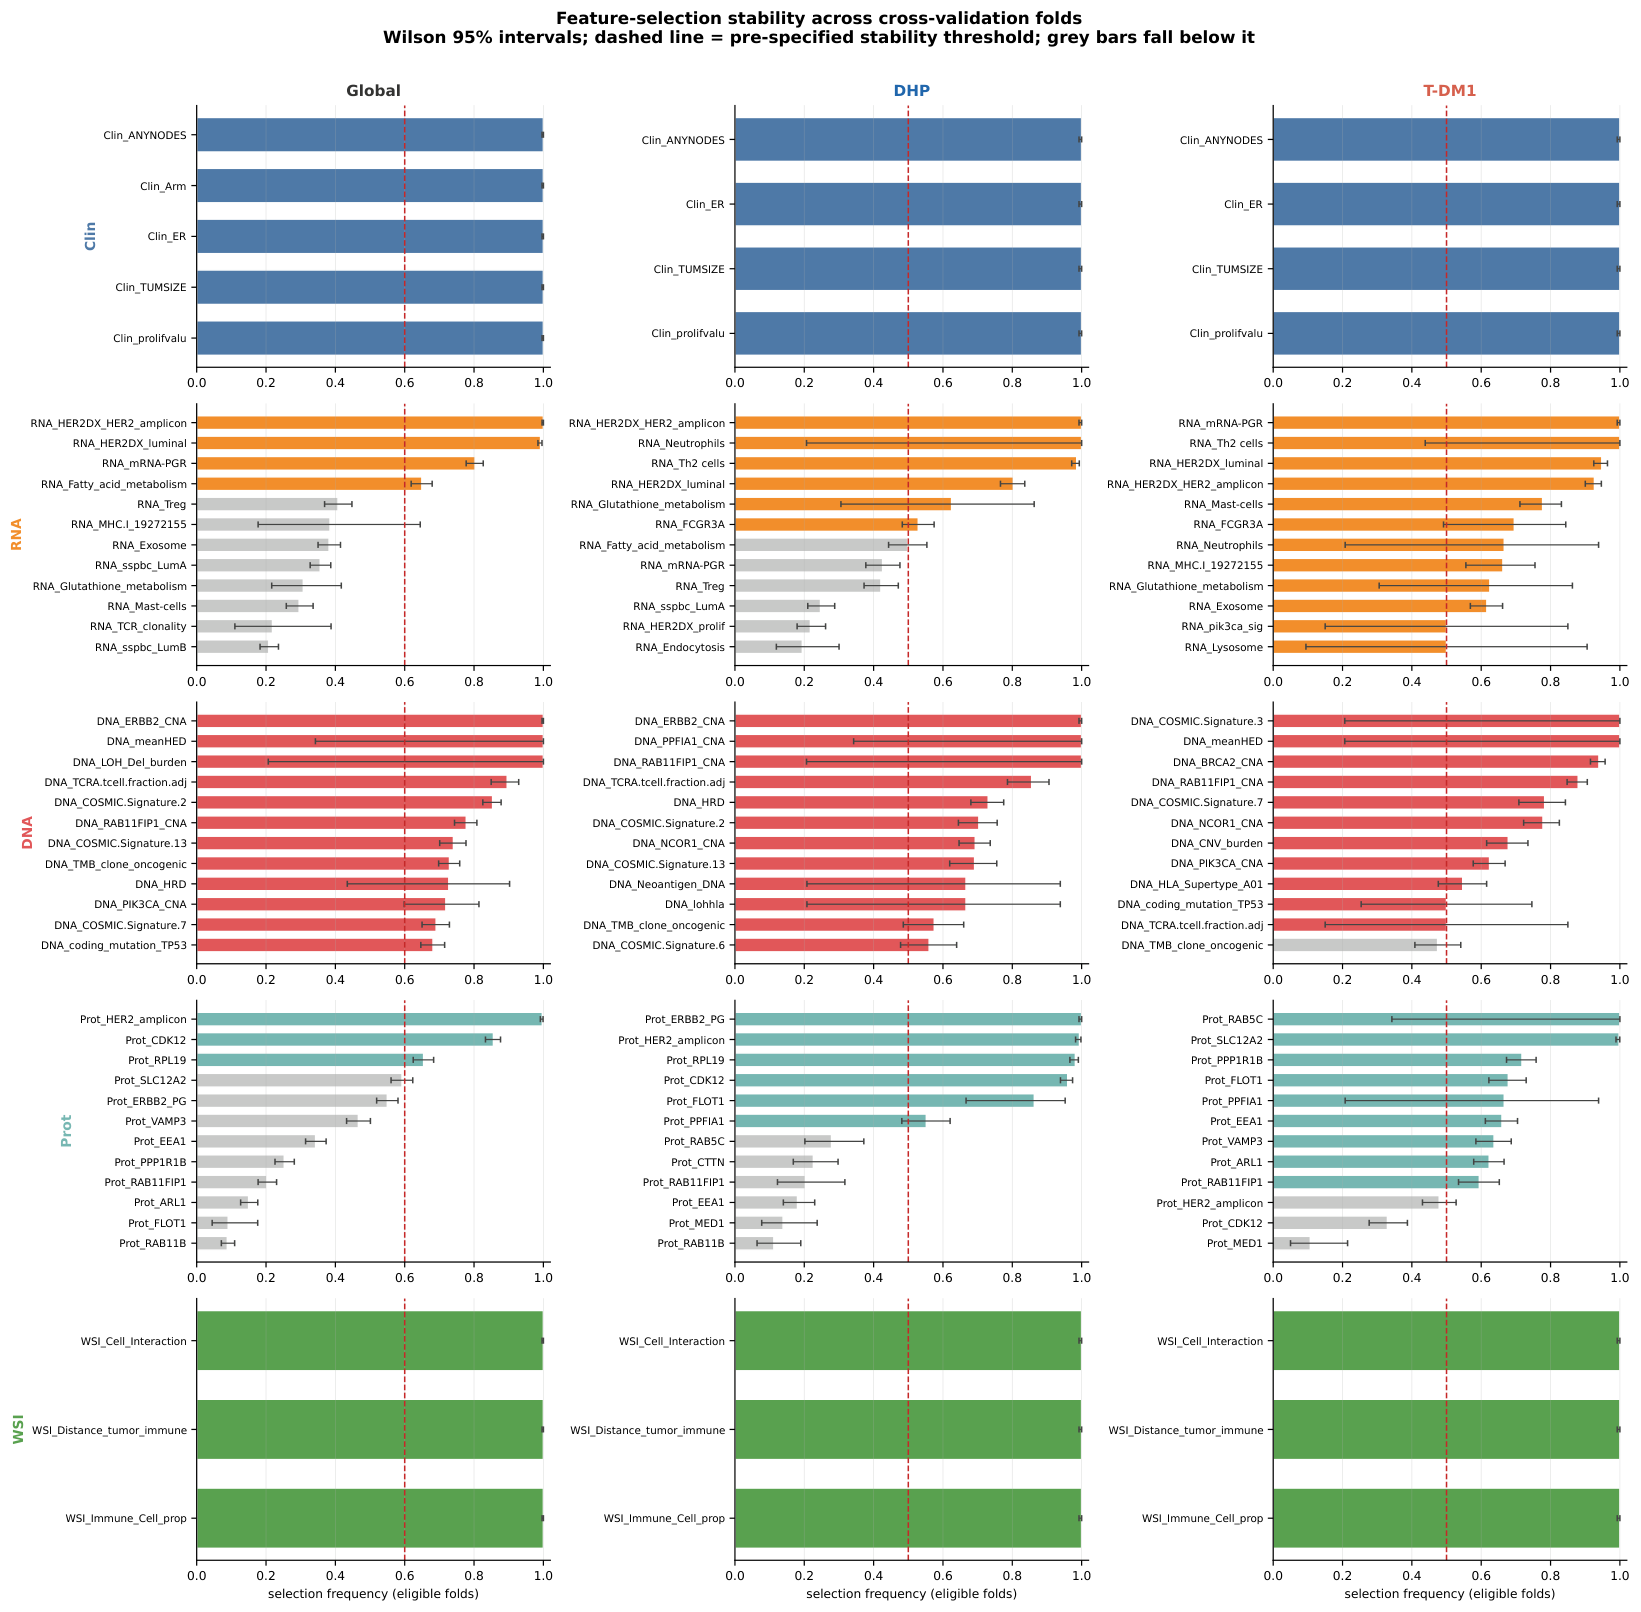

[deposited figure] report/figures/revision/revfig08_fusion_weights.pdf


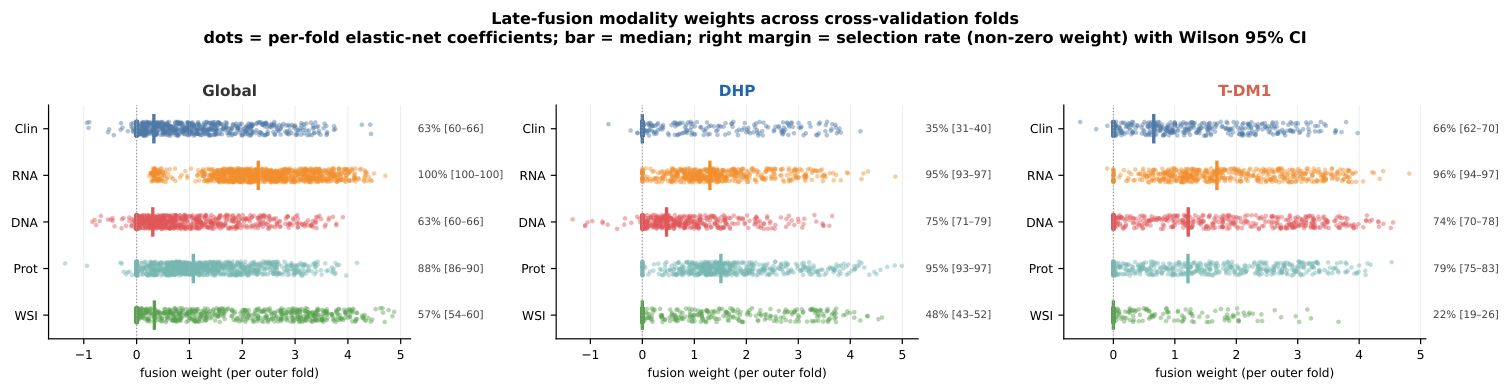

[deposited figure] report/figures/revision/revfig03_epv_per_fold.pdf


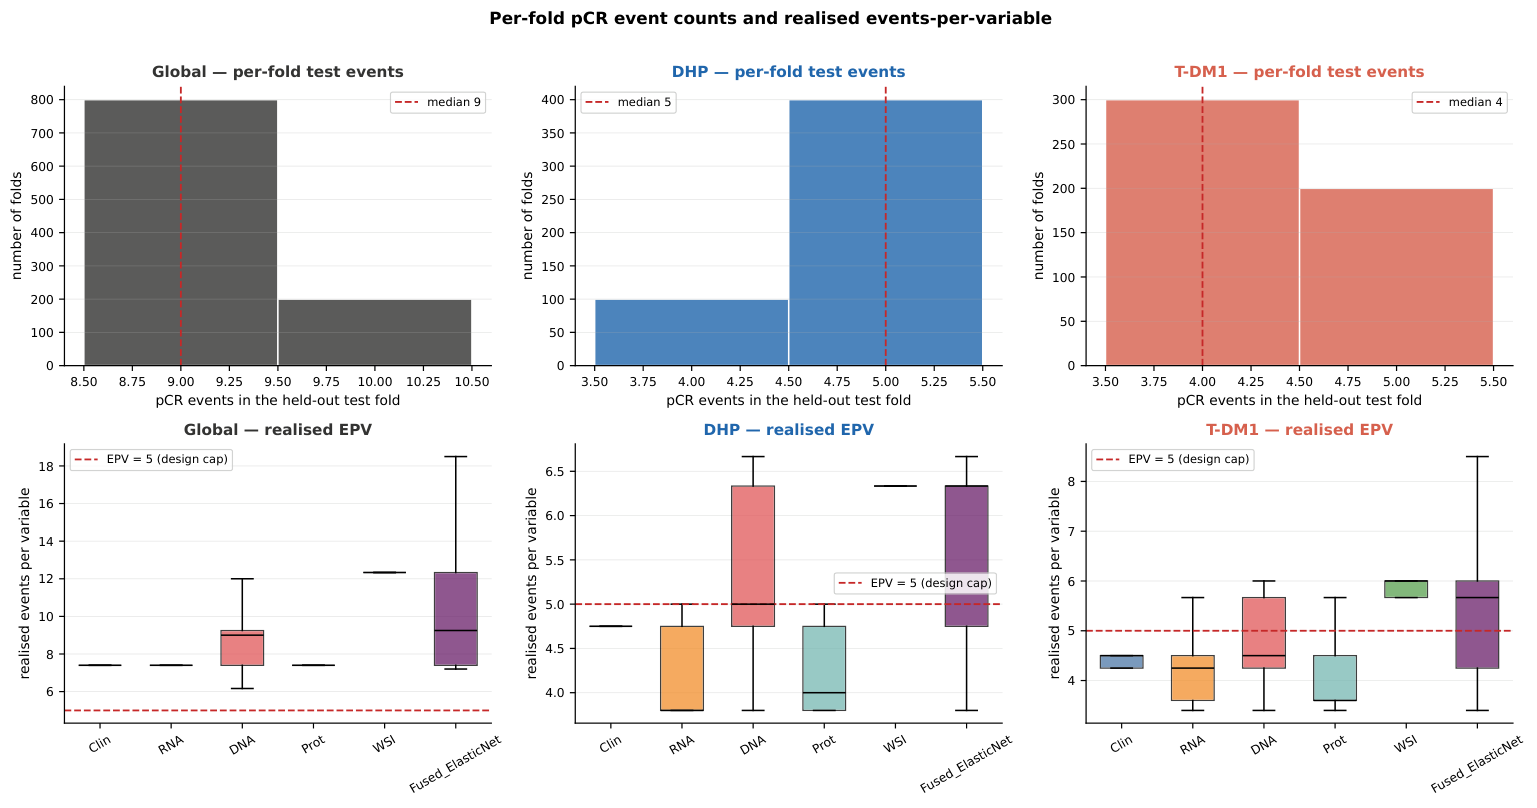

In [12]:
print("=" * 78); print("SECTION 9 — Stability, fusion weights, EPV"); print("=" * 78)
stab = read_sheet(PKG / "report/tables/revision/revision_stability.xlsx",
                  "Feature_selection_stability", "scenario")
print(f"Feature_selection_stability: {len(stab)} rows. Stable features per "
      f"scenario x modality (pre-specified thresholds Global 0.60 / arms 0.50):")
display(stab[stab["stable"] == True].groupby(["scenario", "modality"])
        .size().unstack().reindex(SCENARIOS)[UNIMODALS])
print("\nTop stable Global RNA features (all-fold selection frequency):")
display(stab[(stab.scenario == "Global") & (stab.modality == "RNA")]
        [["feature", "n_selected", "n_folds_total", "selection_freq",
          "selection_freq_eligible", "wilson_low", "stable"]].head(12))

mws = read_sheet(PKG / "report/tables/revision/revision_stability.xlsx",
                 "Modality_weight_stability", "scenario")
print("\nModality_weight_stability (discovery-phase fusion weights):")
display(mws[["scenario", "modality", "n_folds", "selection_rate", "mean_weight",
             "median_weight", "sign_consistency"]].round(3))

epv = read_sheet(PKG / "report/tables/revision/revision_epv_per_fold.xlsx",
                 "EPV_summary", "scenario")
print("\nEPV_summary (realised events-per-variable):")
display(epv[["scenario", "model", "n_folds", "median_n_events_train",
             "median_n_events_test", "median_signature_size",
             "median_epv_realized", "min_epv_realized",
             "pct_folds_epv_below_5"]])

# The cc_only design in one number. Within a scenario every unimodal model
# trains on the SAME patients, so the median training events per fold cannot
# differ across modalities; a difference would mean each model had been fitted
# on its own wider cohort, and the paired comparisons in Sections 5 and 7 would
# no longer be paired.
_ev_train = {sc: sorted({float(v) for v in
                         epv[(epv["scenario"] == sc)
                             & (epv["model"].isin(UNIMODALS))]
                         ["median_n_events_train"]})
             for sc in SCENARIOS}
check("9", "median_n_events_train is identical across all five modalities "
           "within each scenario (the --training_data cc_only design)",
      all(len(v) == 1 for v in _ev_train.values()),
      "; ".join(f"{k} {v}" for k, v in _ev_train.items()))

# ── Recomputation 1: selection frequency from the discovery PKL ──────────────
sf = RA.selection_frequency(DISC["Global"]["RNA"], threshold=0.60)
freq = float(sf.loc[sf.feature == "RNA_HER2DX_HER2_amplicon", "selection_freq"].iloc[0])
wb_freq = float(stab[(stab.scenario == "Global") & (stab.modality == "RNA")
                     & (stab.feature == "RNA_HER2DX_HER2_amplicon")]
                ["selection_freq"].iloc[0])
check("9", "RNA_HER2DX_HER2_amplicon selection frequency (Global RNA, 1000 folds) "
           "recomputed == workbook", close_to(freq, wb_freq),
      f"{freq:.3f} vs {wb_freq:.3f}")

# ── Recomputation 2: fusion selection rate from the consensus folds ──────────
w_rna = np.array([f["modality_weights"]["RNA"] for f in CONS["Global"]["folds"]])
rate = float(np.mean(np.abs(w_rna) > 1e-6))
fus = read_sheet(PKG / "report/tables/PREDIX_HER2_results.xlsx", "Fusion", "Scenario")
wb_rate = float(fus[(fus.Scenario == "Global") & (fus.Modality == "RNA")]
                ["Selection rate (|coef| > 1e-6)"].iloc[0])
check("9", "Global consensus fusion selection rate for RNA recomputed == Fusion "
           "sheet", close_to(round(rate, 3), wb_rate, 1e-12),
      f"recomputed {rate:.3f} vs workbook {wb_rate:.3f}")

# ── Recomputation 3: median test-fold events from the discovery PKL ──────────
ep = RA.epv_table(DISC["Global"][FUSED], "Global", FUSED)
med = float(ep["n_events_test"].median())
check("9", "median test-fold pCR events in Global == 9", med == 9.0, f"median={med:.0f}")

show_pdf(PKG / "report/figures/revision/revfig02_selection_stability.pdf")
show_pdf(PKG / "report/figures/revision/revfig08_fusion_weights.pdf")
show_pdf(PKG / "report/figures/revision/revfig03_epv_per_fold.pdf")

## 10. Consensus signatures

**What this step does.** It displays the locked consensus signature for each
scenario and modality — which features it contains, how large it is, and which
classifier family won — together with the corresponding figures.

**Why it exists.** This is the scientific deliverable a reader is most likely to
want to reuse, so it is shown in full rather than summarised. Two design points
matter for interpreting it. First, the signature is aggregated only over the
outer folds won by the modal classifier (`SIGNATURE_SOURCE = "winner_folds"`), so
the reported classifier and the reported signature describe one model rather than
two loosely related ones. Second, a signature is **not** a ranking of univariate
association: features compete for a limited number of slots inside a
multivariable fit, and a strong marginal predictor can be absent because a
correlated one occupies its slot. The two arm signatures make that concrete:
DHP and T-DM1 draw from the same candidate pool, share three transcriptomic
features, and differ in two — DHP takes the immune features `RNA_Th2 cells` and
`RNA_Treg`, T-DM1 the hormone-receptor transcripts `RNA_mRNA-PGR` and
`RNA_mRNA-ESR1`. It is these arm-specific signatures, frozen exactly as listed
here, that Section 11 carries unchanged into the external cohorts.

**On the importance column.** The `Signatures` sheet reports a normalised
cross-classifier **selection rank**, not a SHAP magnitude, and its header says
so: `Mean selection rank (not |SHAP|)`. The two are not interchangeable — a
selection rank records how consistently a feature was chosen, a SHAP magnitude
how far it moved a prediction — and a wrong label there would be invisible to a
cell-by-cell comparison, so Section 12 asserts the header text rather than
trusting it.

**Reads** the `Signatures` sheet of `report/tables/PREDIX_HER2_results.xlsx` and
the deposited figures. **Writes** nothing.

**What to look for.** Signature sizes and winner classifiers per scenario and
modality, and the absence of any feature named in `TIER1_REMOVE`.

**If it fails.** This section displays rather than asserts; the corresponding
values are checked cell by cell in Section 12.

SECTION 10 — Consensus signatures
Signature sizes and winner classifiers:


,Scenario,Modality,K,winner_classifier
0,DHP,Clin,4,ExtraTrees
1,DHP,DNA,4,ElasticNet_LR
2,DHP,Prot,5,SVM_Linear
3,DHP,RNA,5,SVM_Linear
4,DHP,WSI,3,RandomForest
5,Global,Clin,5,ElasticNet_LR
6,Global,DNA,4,RandomForest
7,Global,Prot,5,SVM_Linear
8,Global,RNA,5,ExtraTrees
9,Global,WSI,3,RandomForest



Full signature listing:


,Scenario,Modality,Rank,Feature,Winner classifier,Signature size (K)
0,Global,Clin,1,Clin_ER,ElasticNet_LR,5
1,Global,Clin,2,Clin_ANYNODES,ElasticNet_LR,5
2,Global,Clin,3,Clin_TUMSIZE,ElasticNet_LR,5
3,Global,Clin,4,Clin_prolifvalu,ElasticNet_LR,5
4,Global,Clin,5,Clin_Arm,ElasticNet_LR,5
5,Global,RNA,1,RNA_HER2DX_HER2_amplicon,ExtraTrees,5
6,Global,RNA,2,RNA_mRNA-PGR,ExtraTrees,5
7,Global,RNA,3,RNA_HER2DX_luminal,ExtraTrees,5
8,Global,RNA,4,RNA_Fatty_acid_metabolism,ExtraTrees,5
9,Global,RNA,5,RNA_sspbc_LumA,ExtraTrees,5


[deposited figure] report/figures/fig02_consensus_signatures.pdf


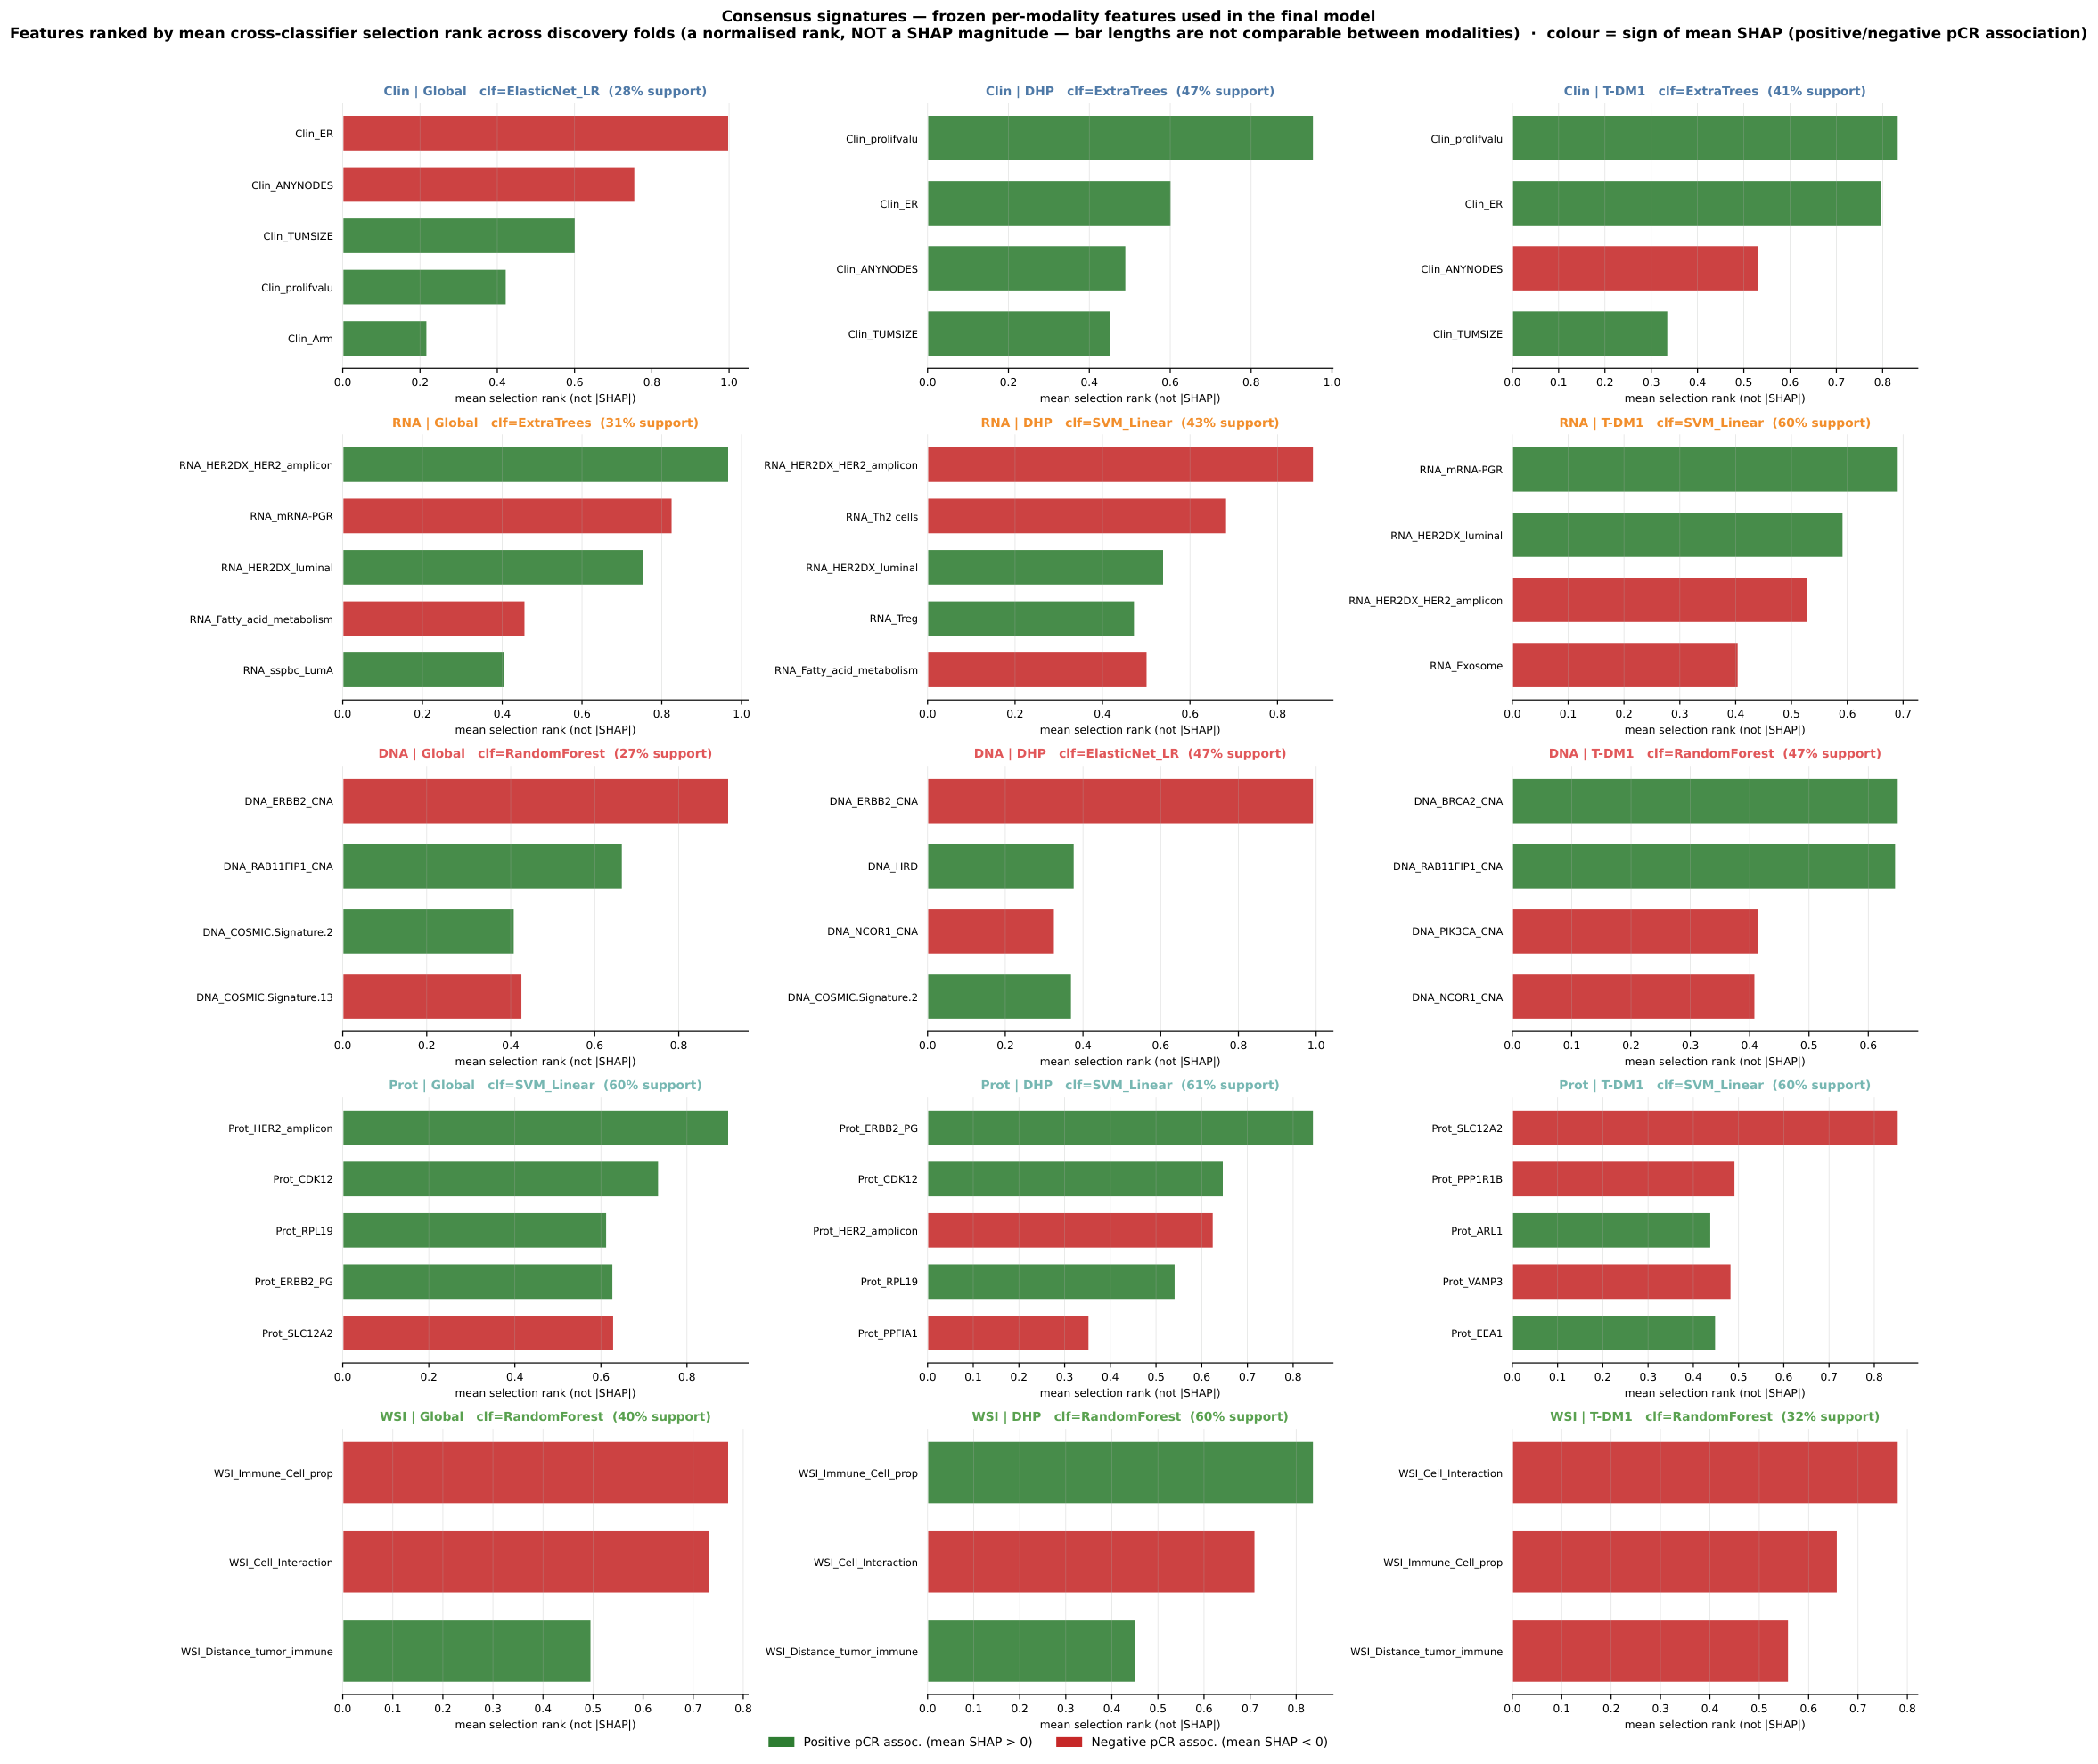

[deposited figure] report/figures/fig05_consensus_feature_shap_Global.pdf


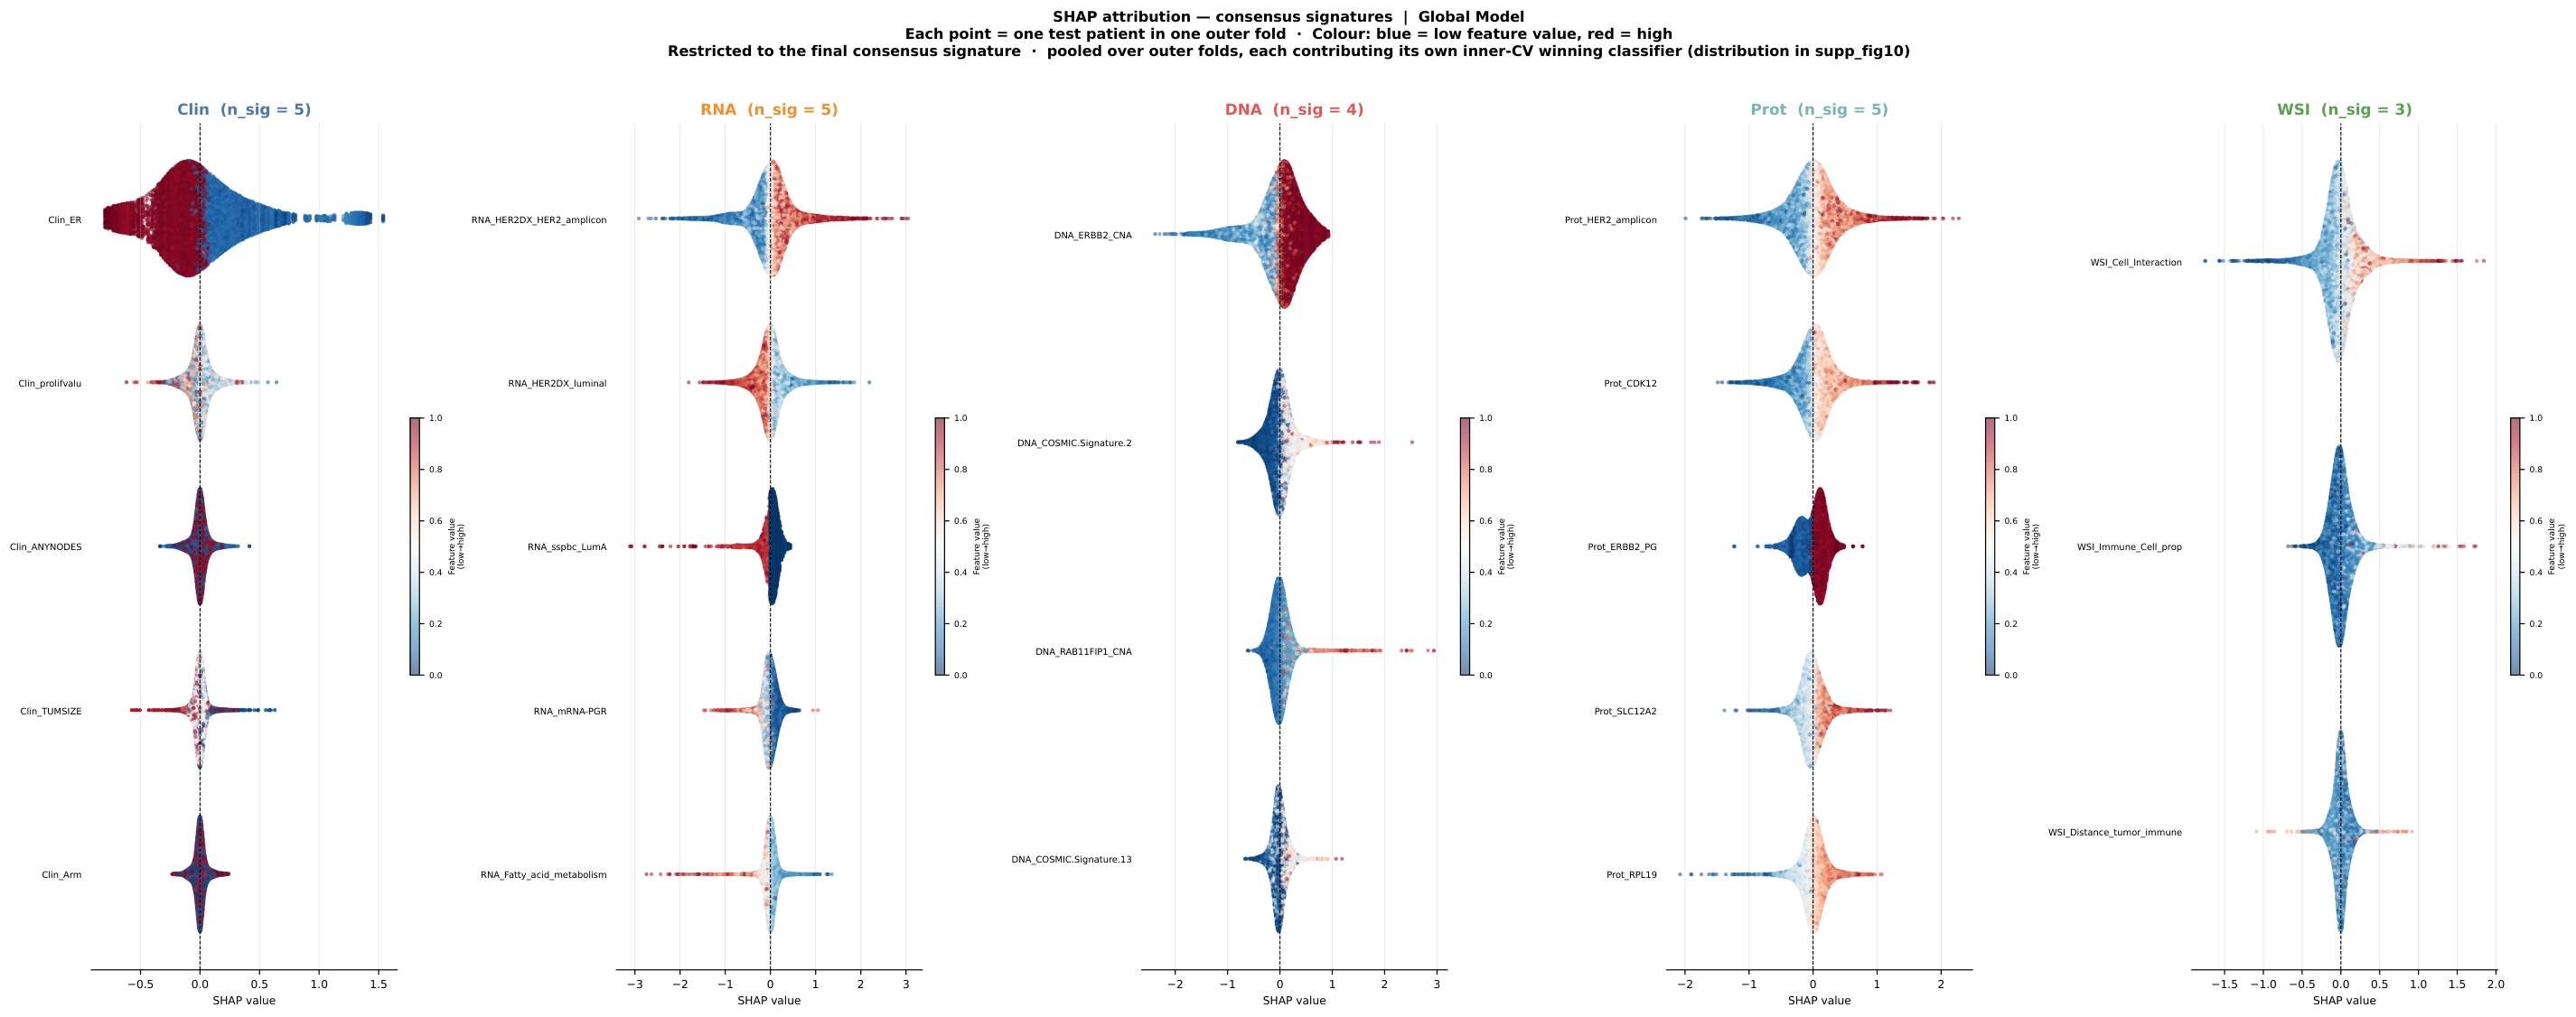

[deposited figure] report/figures/fig05_consensus_feature_shap_DHP.pdf


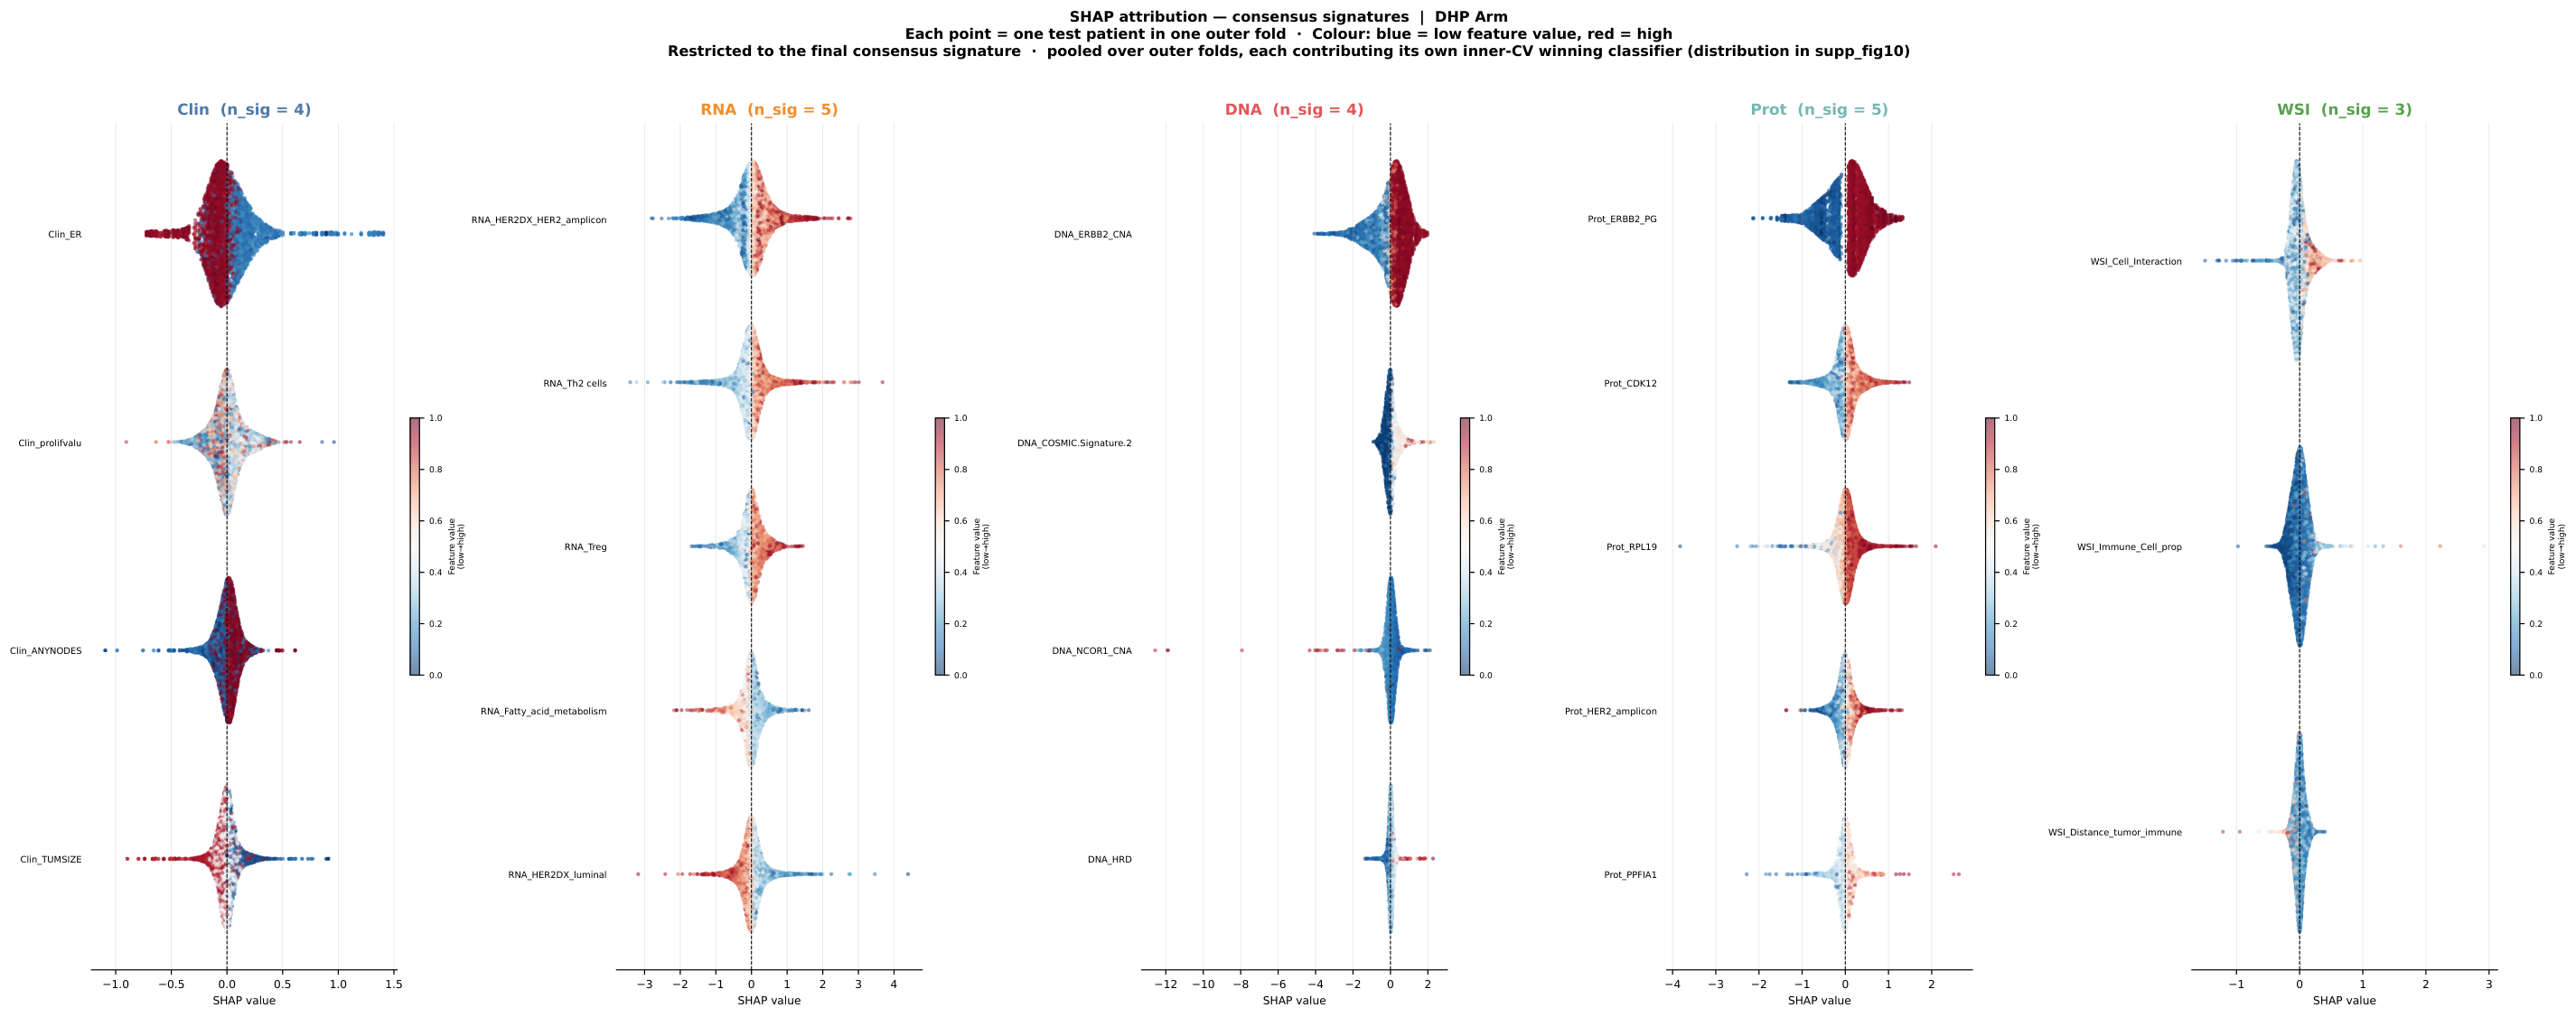

[deposited figure] report/figures/fig05_consensus_feature_shap_T_DM1.pdf


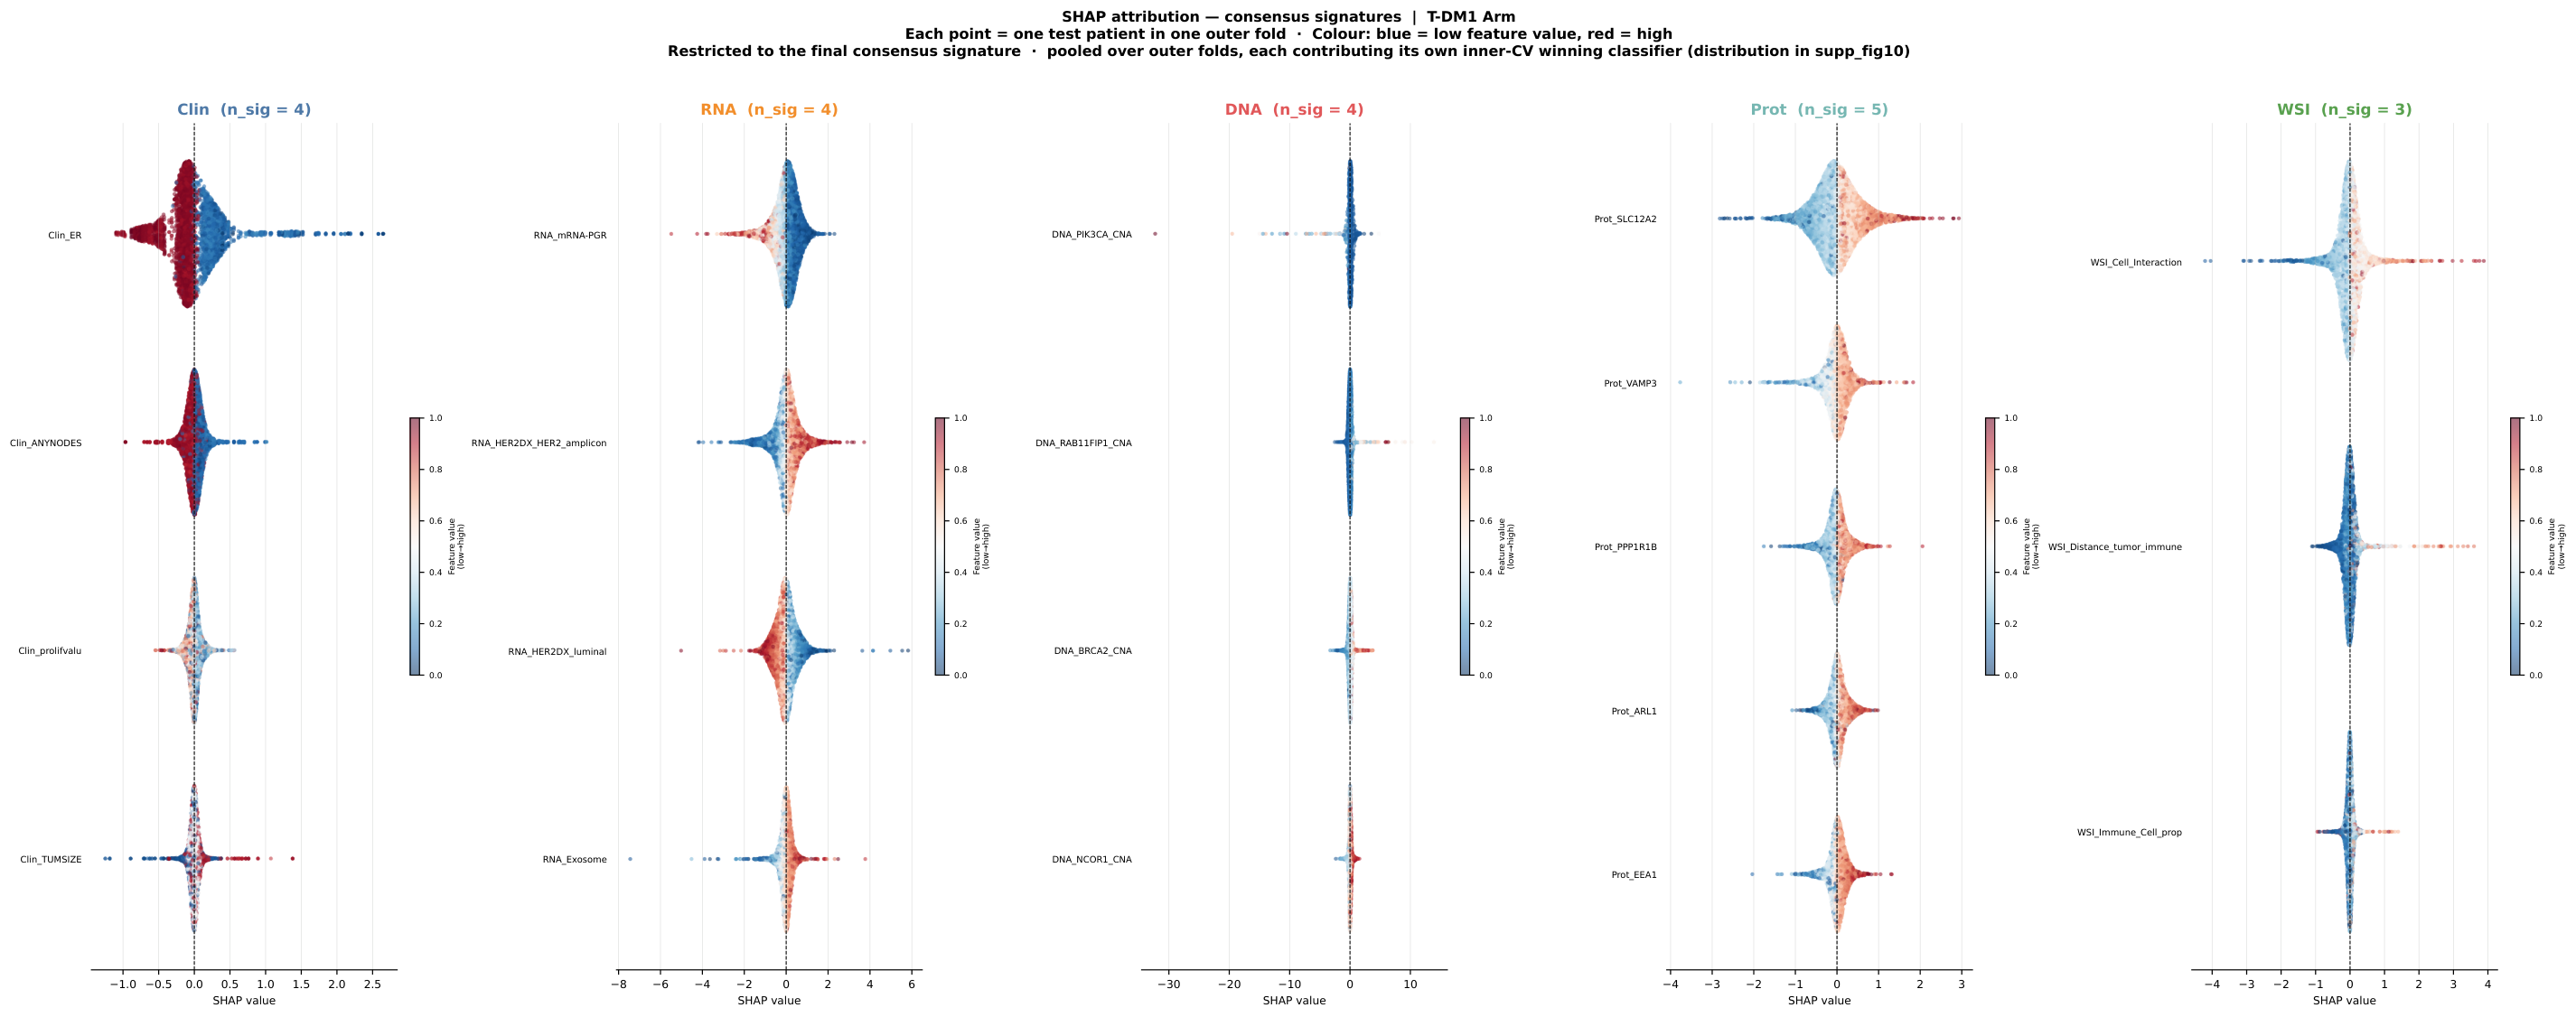

In [13]:
print("=" * 78); print("SECTION 10 — Consensus signatures"); print("=" * 78)
sig = read_sheet(PKG / "report/tables/PREDIX_HER2_results.xlsx", "Signatures", "Scenario")
print("Signature sizes and winner classifiers:")
display(sig.groupby(["Scenario", "Modality"]).agg(
    K=("Signature size (K)", "first"),
    winner_classifier=("Winner classifier", "first")).reset_index())
print("\nFull signature listing:")
display(sig[["Scenario", "Modality", "Rank", "Feature", "Winner classifier",
             "Signature size (K)"]])
show_pdf(PKG / "report/figures/fig02_consensus_signatures.pdf")
for tag in ("Global", "DHP", "T_DM1"):
    show_pdf(PKG / f"report/figures/fig05_consensus_feature_shap_{tag}.pdf")

## 11. External validation of the locked transcriptomic models

**What this step does.** It reports how the pre-specified arm-matched
transcriptomic models, frozen on PREDIX, perform when applied once to each of
three independent public cohorts, and checks the two deposited copies of that
result against one another.

**Why it exists.** Internal cross-validation, however carefully done, cannot rule
out that a signature is tuned to one cohort's idiosyncrasies. External validation
is the answer to that objection, and it is only an answer if nothing is refitted
and nothing is chosen after seeing the result. Both conditions hold here: the
signature, classifier and hyperparameters are frozen before the external data is
touched, the model is fitted once on the corresponding PREDIX cohort with no grid
search and no cross-validation, and it is applied once.

Each cohort is matched to the PREDIX arm whose regimen it resembles — the DHP
model to I-SPY2 (GSE194040) and TransNEO, the T-DM1 model to NCT02326974
(GSE243375). Because the cohorts are measured on incompatible platforms, features
are put on a comparable scale by the per-cohort `zscore` (mean 0, SD 1), computed
within each cohort and without reference to outcome.

Under that harmonisation the three deposited rows are AUROC 0.795 (0.630–0.932),
P = 0.0005 on I-SPY2; 0.665 (0.525–0.798), P = 0.012 on TransNEO; and
0.709 (0.618–0.797), P = 0.0005 on NCT02326974. All three clear chance on the
one-sided test.

**The genomic model is not validatable in the cohorts available.** Its signature
is `DNA_ERBB2_CNA`, `DNA_HRD`, `DNA_NCOR1_CNA`, `DNA_COSMIC.Signature.2`, and three of
the four are not measured in the TransNEO genomic metric file. Scoring a reduced
signature would evaluate a different model, so no number is reported. The entry is
kept in `external_validation/locked_signatures_external_validation.csv` with
`applicable = False` and its missing features named, so the absence is legible
rather than silent.

**Reads** `report/tables/revision/external_validation.xlsx`,
`report/tables/revision/revision_performance_CI.xlsx` for the internal
comparator, and `external_validation/locked_signatures_external_validation.csv`.

**What to look for.** Every `p_vs_chance_one_sided` below 0.05; the internal
comparator in the external workbook matching the performance table (0.808 for
the DHP model, 0.788 for T-DM1); and the two deposited copies of each external
value agreeing to 1e-9. The internal comparator is the second deliberate
departure from the 1e-9 rule: that column is stored to six decimals, so it is
compared at 1e-6, which is the precision the workbook actually holds.

**If it fails.** A mismatch between the workbook and the CSV means one of them was
regenerated or edited alone, and neither should be quoted until that is resolved.


In [14]:
print("=" * 78); print("SECTION 11 — External validation"); print("=" * 78)
EV_COLS = ["cohort", "cohort_resembles_PREDIX_arm", "model_refit_population",
           "arm_matched", "harmonisation", "model_source", "classifier",
           "hyperparameters", "n_model_features", "n_PREDIX_train",
           "events_PREDIX_train", "internal_AUROC_CI", "n_external",
           "events_external", "external_AUROC_CI", "external_AUPRC",
           "external_Brier", "calibration_slope", "p_vs_chance_one_sided"]

EV = read_sheet(PKG / "report/tables/revision/external_validation.xlsx",
                "External_validation", "cohort")
print("Locked models applied once, arm-matched — "
      "report/tables/revision/external_validation.xlsx")
display(EV[EV_COLS].round(4))

# Every deposited row must clear chance. Features are harmonised by the
# per-cohort z-score; the filter below selects those rows explicitly rather than
# assuming the sheet contains only one scheme.
print("\nAbove-chance test on the reported harmonisation (zscore):")
for _co in ("I-SPY2", "TransNEO", "NCT02326974"):
    _sel = EV[(EV.cohort == _co) & (EV.harmonisation == "zscore")]
    check("11", f"{_co}: a zscore row is present", len(_sel) == 1, f"{len(_sel)} rows")
    _r = _sel.iloc[0]
    check("11", f"{_co}: external AUROC is above chance",
          float(_r["external_AUROC"]) > 0.5
          and float(_r["p_vs_chance_one_sided"]) < 0.05,
          f"AUROC {float(_r['external_AUROC']):.3f}, one-sided P "
          f"{float(_r['p_vs_chance_one_sided']):.4f}")

# The internal comparator is carried in the workbook, read from the main run's
# performance table when the workbook was built. Assert it matches that table,
# so the two deposited copies of the same quantity cannot drift apart.
_perf = read_sheet(PKG / "report/tables/revision/revision_performance_CI.xlsx",
                   "Performance_patient_CI", "scenario")
_perf = _perf[_perf["source"].astype(str).str.strip() == "consensus"]
for _, _r in EV.iterrows():
    _scen = str(_r["cohort_resembles_PREDIX_arm"]).strip()
    _m = _perf[(_perf["scenario"].astype(str).str.strip() == _scen)
               & (_perf["model"].astype(str).str.strip() == "RNA")]
    # 1e-6, not close_to's 1e-9: the workbook stores this value rounded to six
    # decimals on purpose, so a tighter tolerance would test the storage format
    # rather than the agreement.
    _d = (abs(float(_m.iloc[0]["AUROC"]) - float(_r["internal_AUROC"]))
          if len(_m) == 1 else float("nan"))
    check("11", f"{_r['cohort']}: internal comparator matches the performance table",
          len(_m) == 1 and _d < 1e-6,
          f"workbook {float(_r['internal_AUROC']):.6f}, table "
          f"{float(_m.iloc[0]['AUROC']):.6f}, |diff| {_d:.2e}")

print("\nFeature provenance (what each cohort measures, and what it does not):")
_prov = read_sheet(PKG / "report/tables/revision/external_validation.xlsx",
                   "Feature_provenance", "cohort")
display(_prov)

# A model that cannot be scored must SAY which features are missing. Silence
# here would be indistinguishable from a validation that was quietly dropped.
_absent = _prov[_prov["status"].astype(str).str.upper() == "ABSENT"]
check("11", "every unmeasured signature feature is named, not silently omitted",
      len(_absent) > 0 and _absent["feature"].astype(str).str.strip().all(),
      f"{len(_absent)} feature(s) recorded absent: "
      f"{sorted(set(_absent['feature'].astype(str)))}")


SECTION 11 — External validation
Locked models applied once, arm-matched — report/tables/revision/external_validation.xlsx


,cohort,cohort_resembles_PREDIX_arm,model_refit_population,arm_matched,harmonisation,model_source,classifier,hyperparameters,n_model_features,n_PREDIX_train,events_PREDIX_train,internal_AUROC_CI,n_external,events_external,external_AUROC_CI,external_AUPRC,external_Brier,calibration_slope,p_vs_chance_one_sided
0,I-SPY2,DHP,"PREDIX DHP arm, complete cases only",True,zscore,locked consensus (complete-case training),SVM_Linear,{'C': 0.1},5,59,24,0.808 [0.704–0.900],44,26,0.795 [0.630–0.932],0.7786,0.2245,0.7668,0.0005
1,TransNEO,DHP,"PREDIX DHP arm, complete cases only",True,zscore,locked consensus (complete-case training),SVM_Linear,{'C': 0.1},5,59,24,0.808 [0.704–0.900],60,19,0.665 [0.525–0.798],0.4317,0.2339,0.3779,0.0125
2,NCT02326974,T-DM1,"PREDIX T-DM1 arm, complete cases only",True,zscore,locked consensus (complete-case training),SVM_Linear,{'C': 0.1},4,51,22,0.788 [0.655–0.900],129,64,0.709 [0.618–0.797],0.7140,0.2295,0.6384,0.0005



Above-chance test on the reported harmonisation (zscore):
  [PASS] I-SPY2: a zscore row is present  (1 rows)
  [PASS] I-SPY2: external AUROC is above chance  (AUROC 0.795, one-sided P 0.0005)
  [PASS] TransNEO: a zscore row is present  (1 rows)
  [PASS] TransNEO: external AUROC is above chance  (AUROC 0.665, one-sided P 0.0125)
  [PASS] NCT02326974: a zscore row is present  (1 rows)
  [PASS] NCT02326974: external AUROC is above chance  (AUROC 0.709, one-sided P 0.0005)
  [PASS] I-SPY2: internal comparator matches the performance table  (workbook 0.807643, table 0.807643, |diff| 1.43e-07)
  [PASS] TransNEO: internal comparator matches the performance table  (workbook 0.807643, table 0.807643, |diff| 1.43e-07)
  [PASS] NCT02326974: internal comparator matches the performance table  (workbook 0.788401, table 0.788401, |diff| 2.54e-07)

Feature provenance (what each cohort measures, and what it does not):


,cohort,feature,status,reason
0,I-SPY2,RNA_HER2DX_HER2_amplicon,present,measured in this cohort
1,I-SPY2,RNA_Th2 cells,present,measured in this cohort
2,I-SPY2,RNA_HER2DX_luminal,present,measured in this cohort
3,I-SPY2,RNA_Treg,present,measured in this cohort
4,I-SPY2,RNA_Fatty_acid_metabolism,present,measured in this cohort
5,TransNEO,RNA_HER2DX_HER2_amplicon,present,measured in this cohort
6,TransNEO,RNA_Th2 cells,present,measured in this cohort
7,TransNEO,RNA_HER2DX_luminal,present,measured in this cohort
8,TransNEO,RNA_Treg,present,measured in this cohort
9,TransNEO,RNA_Fatty_acid_metabolism,present,measured in this cohort


  [PASS] every unmeasured signature feature is named, not silently omitted  (3 feature(s) recorded absent: ['DNA_COSMIC.Signature.2', 'DNA_HRD', 'DNA_NCOR1_CNA'])


True

In [15]:
# ── The two deposited copies of the external validation must agree ──────────
# A from-source re-run is not possible inside a deposit: the no-patient-data
# variant withholds the PREDIX matrix, and the TransNEO metrics are third-party
# and are not redistributed. What CAN be checked, and matters, is that the two
# places this result is deposited say the same thing:
#
#   report/tables/revision/external_validation.xlsx   (read by RESULTS.md)
#   external_validation/locked_signatures_external_validation.csv
#
# They are written by the same script from the same objects, so any divergence
# means one of them was edited or regenerated alone.
import pandas as _pd

_CSV = PKG / "external_validation" / "locked_signatures_external_validation.csv"
check("11", "the external_validation/ CSV is deposited", _CSV.is_file(),
      relpath(_CSV))

_csv = _pd.read_csv(_CSV)
_ok = _csv[_csv["applicable"].astype(bool)]
_no = _csv[~_csv["applicable"].astype(bool)]
print(f"CSV: {len(_ok)} applicable validation set(s), "
      f"{len(_no)} recorded as not validatable")

check("11", "the CSV and the workbook cover the same cohorts",
      sorted(_ok["cohort"].astype(str)) == sorted(EV["cohort"].astype(str)),
      f"CSV {sorted(_ok['cohort'].astype(str))} vs "
      f"workbook {sorted(EV['cohort'].astype(str))}")

_maxd = 0.0
for _, _r in _ok.iterrows():
    _w = EV[EV.cohort == _r["cohort"]].iloc[0]
    for _col_csv, _col_wb in (("external_AUROC", "external_AUROC"),
                              ("external_AUROC_p_vs_chance_one_sided",
                               "p_vs_chance_one_sided"),
                              ("calibration_slope", "calibration_slope")):
        _maxd = max(_maxd, abs(float(_r[_col_csv]) - float(_w[_col_wb])))
check("11", "every external value agrees between the CSV and the workbook",
      _maxd < 1e-9, f"max |difference| = {_maxd:.2e}")

# The genomic model is not validatable here. That is a reportable finding, not a
# gap: it is asserted to be present and explained rather than merely absent.
check("11", "the non-validatable model is recorded with its missing features",
      len(_no) >= 1
      and _no["missing_features"].astype(str).str.strip().astype(bool).all(),
      f"{len(_no)} row(s): {[str(v)[:60] for v in _no['missing_features']]}")
T_EXTVAL = 0.0


  [PASS] the external_validation/ CSV is deposited  (external_validation/locked_signatures_external_validation.csv)
CSV: 3 applicable validation set(s), 1 recorded as not validatable
  [PASS] the CSV and the workbook cover the same cohorts  (CSV ['I-SPY2', 'NCT02326974', 'TransNEO'] vs workbook ['I-SPY2', 'NCT02326974', 'TransNEO'])
  [PASS] every external value agrees between the CSV and the workbook  (max |difference| = 0.00e+00)
  [PASS] the non-validatable model is recorded with its missing features  (1 row(s): ['DNA_HRD; DNA_NCOR1_CNA; DNA_COSMIC.Signature.2'])


## 12. Full regeneration of the deposited report

**What this step does.** It re-runs the two post-processing scripts end to end on
the deposited fold-level artefacts, writing a complete second copy of the report
into `_regenerated/`, and then compares every regenerated workbook with its
deposited counterpart sheet by sheet and cell by cell, in natural row order —
strings exactly, numbers to 1e-9.

**Why it exists.** Sections 5 to 11 verify the numbers a reader is most likely to
quote. This section verifies **everything else**: every cell of every deposited
table, including the ones nobody thought to spot-check. It is what converts the
claim "these tables came from these artefacts" from an assertion into a
demonstration, and it is the check that would catch a table edited by hand after
the fact.

**No cell is exempt.** Every cell of every compared workbook — every AUROC,
interval, p-value, selection frequency, weight, count and label — must match,
and no column is skipped. One workbook is excluded from the sweep as a whole,
`revision/external_validation.xlsx`, because it is written by a separate script
that needs external cohort files this deposit does not carry in full. The cell
asserts that it is nevertheless present, so "excluded" and "missing" cannot look
the same, and Section 11 verifies it row by row against the deposited
external-validation CSV and against the performance table.

**Two checks run after the sweep**, on content a cell-by-cell comparison cannot
catch: if the code that writes a description were wrong, both the deposited and
the regenerated copy would carry the same wrong text and match each other
perfectly. The first parses the `Methodology` sheet of
`supp_PREDIX_HER2_feature_pruning_report.xlsx` and requires it to list exactly
the `TIER1_REMOVE` features found in the pipeline source shipped in `code/`, so
a written description of the feature panel cannot drift from the panel the code
applies. The second requires the `Signatures` rank column of
`PREDIX_HER2_results.xlsx` to be labelled `Mean selection rank (not |SHAP|)`,
which is what that column holds.

*A note on row order, kept because it shows what this section is for.* Sheets are
compared in their natural row order, with no canonicalisation and no sorting by
key. That is only safe because the row order is deterministic:
`selection_frequency()` sorts by `(selection_freq_eligible, selection_freq,
feature)` with a stable sort, so features tied at the same frequency cannot be
emitted in a different order between two processes with different string-hash
seeds, and the test suite checks that ordering. Comparing in natural order keeps
the check strict — a regression in row ordering fails here instead of being
canonicalised away.

**Reads** `results/`, `data/`, `code/generate_report.py`,
`code/revision_analyses.py` and everything under `report/tables/`.
**Writes** the full regenerated report into `_regenerated/`, which is scratch:
it is excluded from `MANIFEST_SHA256.txt` and is not shipped.

**What to look for.** Total mismatches zero, across roughly 180,000 compared
cells. Every deposited workbook is compared except
`revision/external_validation.xlsx`, and every deposited figure is regenerated
except `revision/revfig06_external_validation.pdf`, for the same reason in both
cases. The cell prints how many workbooks were deposited and how many were
compared, so those two counts are read off the output rather than taken from
this paragraph. Figure PDFs are compared by presence rather than by bytes,
because they embed a creation timestamp.

**If it fails.** A first-mismatch line naming a numeric cell means the deposited
tables were not produced from the deposited artefacts by the shipped code, which
is the most serious failure this notebook can report. A mismatch in a text cell
usually means code and tables have drifted in wording only — check whether the
regenerated value is the correct one before assuming the deposit is at
fault.

In [16]:
print("=" * 78); print("SECTION 12a — generate_report.py on the deposited PKLs"); print("=" * 78)
t0 = time.time()
r = subprocess.run([sys.executable, "code/generate_report.py",
                    "--results_dir", "results", "--out_dir", "_regenerated"],
                   capture_output=True, text=True,
                   encoding="utf-8", errors="replace", cwd=str(PKG))
T_GENREP = time.time() - t0
print(f"exit code {r.returncode} after {T_GENREP/60:.1f} min; last 8 lines:\n")
print("\n".join(r.stdout.strip().splitlines()[-8:]))
if r.returncode != 0:
    print("\nSTDERR (tail):\n", r.stderr[-4000:])
check("12", "generate_report.py completed", r.returncode == 0)

SECTION 12a — generate_report.py on the deposited PKLs


exit code 0 after 3.3 min; last 8 lines:

  → PREDIX_HER2_results.xlsx
  → PREDIX_HER2_performance_CI.xlsx
  → PREDIX_HER2_feature_pruning_report.xlsx
  → pooled_operating_points.xlsx

Done.  Main-text figures  (8) → _regenerated\figures
       Supplementary figs (16) → _regenerated\figures\supplementary
       Tables            → _regenerated\tables
  [PASS] generate_report.py completed


True

In [17]:
print("=" * 78); print("SECTION 12b — revision_analyses.py on the deposited PKLs"); print("=" * 78)
t0 = time.time()
# ---- NO-PATIENT-DATA VARIANT (inserted by build_github_repo.py) ----
_cmd = [sys.executable, "code/revision_analyses.py",
        "--results_dir", "results", "--out_dir", "_regenerated",
        "--n_boot", "2000"]
if NO_PATIENT_DATA:
    print("[NO PATIENT DATA] --data_path omitted. It feeds only the exploratory "
          "survival section, which is inert in this dataset (the input file "
          "carries no follow-up columns), so this section is COMPLETE: every "
          "table and figure revision_analyses.py writes comes from results/.")
else:
    _cmd += ["--data_path", "data/clin_multiomics_curated_metrics_PREDIX_HER2_new.txt"]
# ---- end NO-PATIENT-DATA VARIANT ----
r = subprocess.run(_cmd,
                   capture_output=True, text=True,
                   encoding="utf-8", errors="replace", cwd=str(PKG))
T_REVAN = time.time() - t0
print(f"exit code {r.returncode} after {T_REVAN/60:.1f} min; last 10 lines:\n")
print("\n".join(r.stdout.strip().splitlines()[-10:]))
if r.returncode != 0:
    print("\nSTDERR (tail):\n", r.stderr[-4000:])
check("12", "revision_analyses.py completed", r.returncode == 0)

SECTION 12b — revision_analyses.py on the deposited PKLs
[NO PATIENT DATA] --data_path omitted. It feeds only the exploratory survival section, which is inert in this dataset (the input file carries no follow-up columns), so this section is COMPLETE: every table and figure revision_analyses.py writes comes from results/.


exit code 0 after 3.5 min; last 10 lines:


[5/5] Paired model comparisons ...
  -> revision_model_comparisons.xlsx
  -> revfig07_model_comparisons.pdf

REVISION ANALYSES COMPLETE
  Tables  -> _regenerated\tables\revision
  Figures -> _regenerated\figures\revision
  [PASS] revision_analyses.py completed


True

In [18]:
# ── Cell-by-cell comparison of every regenerated workbook ───────────────────
from openpyxl.utils import get_column_letter

def sheet_grid(ws):
    return [[c.value for c in row] for row in ws.iter_rows()]

def cells_equal(va, vb):
    if va is None or vb is None:
        return va is None and vb is None
    if isinstance(va, bool) or isinstance(vb, bool):
        return va == vb
    if isinstance(va, (int, float)) and isinstance(vb, (int, float)):
        return close_to(va, vb)
    return va == vb

def canonicalise(grid, first_header, n_key):
    # Sort the body rows (below the header row that starts with `first_header`)
    # by their first n_key columns. Returns (grid, n_moved).
    hdr_i = next((i for i, r in enumerate(grid) if r and r[0] == first_header), None)
    if hdr_i is None:
        return grid, 0
    head, body = grid[:hdr_i + 1], grid[hdr_i + 1:]
    key = lambda r: tuple(str(v) for v in r[:n_key])
    body_sorted = sorted(body, key=key)
    n_moved = sum(1 for a, b in zip(body, body_sorted) if key(a) != key(b))
    return head + body_sorted, n_moved

def compare_workbooks(dep_path, reg_path, skip_cols=None, key_sheets=None):
    wa = openpyxl.load_workbook(dep_path, data_only=True)
    wb_ = openpyxl.load_workbook(reg_path, data_only=True)
    out = dict(n_sheets=len(wa.sheetnames), n_cells=0, n_mismatch=0,
               n_skipped=0, n_reordered=0, first="", skipped_examples=[])
    if wa.sheetnames != wb_.sheetnames:
        out["n_mismatch"] = -1
        out["first"] = f"sheet names differ: {wa.sheetnames} vs {wb_.sheetnames}"
        return out
    for sn in wa.sheetnames:
        ga, gb = sheet_grid(wa[sn]), sheet_grid(wb_[sn])
        if key_sheets and sn in key_sheets:
            first_header, n_key = key_sheets[sn]
            ga, m_a = canonicalise(ga, first_header, n_key)
            gb, m_b = canonicalise(gb, first_header, n_key)
            out["n_reordered"] += max(m_a, m_b)
        skip_idx, hdr_row = set(), None
        names = (skip_cols or {}).get(sn, [])
        if names:
            for ri, row in enumerate(ga[:40]):
                hits = [ci for ci, v in enumerate(row) if v in names]
                if hits:
                    skip_idx, hdr_row = set(hits), ri
                    break
        n_rows = max(len(ga), len(gb))
        for ri in range(n_rows):
            ra = ga[ri] if ri < len(ga) else []
            rb = gb[ri] if ri < len(gb) else []
            n_c = max(len(ra), len(rb))
            for ci in range(n_c):
                va = ra[ci] if ci < len(ra) else None
                vb = rb[ci] if ci < len(rb) else None
                if ci in skip_idx and hdr_row is not None and ri > hdr_row:
                    if not cells_equal(va, vb):
                        out["n_skipped"] += 1
                        out["skipped_examples"].append(
                            f"{sn}!{get_column_letter(ci+1)}{ri+1}: {va!r} vs {vb!r}")
                    continue
                out["n_cells"] += 1
                if not cells_equal(va, vb):
                    out["n_mismatch"] += 1
                    if not out["first"]:
                        out["first"] = (f"{sn}!{get_column_letter(ci+1)}{ri+1}: "
                                        f"deposited {va!r} vs regenerated {vb!r}")
    return out

# ── Regenerated before the sweep below, not by generate_report.py ───────────
# fig_feature_ranking_by_scope is drawn by its own script rather than by
# generate_report.py, so it has to be regenerated explicitly here or the sweep
# would report its workbook as MISSING. It needs nothing but results/ — the
# frozen consensus signatures and the per-fold SHAP arrays — so it reproduces
# from first principles like everything else in this section. Its figure goes to
# the regenerated figure tree and the workbook of the values it plots to the
# regenerated table tree, so the comparison immediately below covers the
# workbook cell by cell and the presence check at the end covers the figure.
_frk = subprocess.run([sys.executable, "code/make_fig_feature_ranking.py",
                       "--run", ".",
                       "--out", "_regenerated/figures/revision",
                       "--table-out", "_regenerated/tables/revision"],
                      capture_output=True, text=True,
                      encoding="utf-8", errors="replace", cwd=str(PKG))
if _frk.returncode != 0:
    print(_frk.stdout[-1500:])
    print(_frk.stderr[-1500:])
assert _frk.returncode == 0, "make_fig_feature_ranking.py failed; see output above"
print("regenerated fig_feature_ranking_by_scope and its value workbook "
      "from results/")

dep_root = PKG / "report" / "tables"
reg_root = PKG / "_regenerated" / "tables"
# NOT REGENERATED HERE, AND SAID SO RATHER THAN COUNTED AS A MISMATCH.
# external_validation.xlsx is produced by a separate script that needs the
# external cohort files; those are third-party and are not all redistributed, so
# this sweep cannot rebuild it. It is NOT unverified: Section 11 compares it,
# row by row, against the deposited external_validation/ CSV and against the
# performance table. Excluding it here keeps "this workbook did not reproduce"
# meaning what it says.
NOT_REGENERABLE = {"revision/external_validation.xlsx"}

dep_files = sorted(p.relative_to(dep_root).as_posix() for p in dep_root.rglob("*.xlsx"))
reg_files = sorted(p.relative_to(reg_root).as_posix() for p in reg_root.rglob("*.xlsx"))
# ---- NO-PATIENT-DATA VARIANT (inserted by build_github_repo.py) ----
if NO_PATIENT_DATA:
    _nd_wb = [f for f in dep_files if "external_validation" in f]
    dep_files = [f for f in dep_files if f not in _nd_wb]
    # Guarded: the external-validation workbook is already excluded from this
    # sweep in both variants, so this list is normally empty and printing it
    # would announce an exclusion that did not happen.
    if _nd_wb:
        print("[NO PATIENT DATA] not compared, because they cannot be "
              "regenerated without the withheld input matrix: "
              + ", ".join(_nd_wb) + ". The DEPOSITED copies are unaffected and "
              "are checked in Section 11.")
# ---- end NO-PATIENT-DATA VARIANT ----
# An excluded file must still EXIST. Otherwise "excluded" and "lost" look the
# same, which is how a deposit quietly stops containing something.
for _nr in sorted(NOT_REGENERABLE):
    check("12", f"{_nr} is deposited (excluded from the regeneration sweep)",
          (dep_root / _nr).is_file(), relpath(dep_root / _nr))
dep_files = [f for f in dep_files if f not in NOT_REGENERABLE]
print(f"deposited workbooks: {len(dep_files) + len(NOT_REGENERABLE)}; "
      f"regenerated and compared: {len(reg_files)}; "
      f"excluded as not regenerable here: {sorted(NOT_REGENERABLE)}")
extras = sorted(set(reg_files) - set(dep_files))
if extras:
    print("regenerated-only files (not deposited):", extras)

# SKIP is the mechanism for exempting a single COLUMN from the comparison, and
# it is deliberately EMPTY: no column is exempt. Leaving it empty is what makes
# a column that stops reproducing fail here rather than be skipped past. (The
# one workbook this sweep cannot rebuild is excluded whole, above, and is
# verified in Section 11 instead.)
SKIP = {}
# KEYED is the mechanism for sorting a sheet's rows before comparing, and it is
# empty for the same reason. Row order is deterministic — selection_frequency()
# sorts by (selection_freq_eligible, selection_freq, feature) with a stable sort
# — so every sheet is compared in its natural row order, and a regression in row
# ordering fails here instead of being canonicalised away.
KEYED = {}

t0 = time.time()
summary, total_bad, total_skipped = [], 0, 0
for rel in dep_files:
    reg = reg_root / rel
    if not reg.exists():
        summary.append(dict(file=rel, sheets=0, cells_compared=0, mismatches=-1,
                            skipped_cells=0,
                            first_mismatch="MISSING in _regenerated"))
        total_bad += 1
        continue
    res = compare_workbooks(dep_root / rel, reg, skip_cols=SKIP.get(rel),
                            key_sheets=KEYED.get(rel))
    summary.append(dict(file=rel, sheets=res["n_sheets"], cells_compared=res["n_cells"],
                        mismatches=res["n_mismatch"], skipped_cells=res["n_skipped"],
                        first_mismatch=res["first"]))
    total_bad += max(res["n_mismatch"], 0) + (1 if res["n_mismatch"] < 0 else 0)
    total_skipped += res["n_skipped"]
    for ex in res["skipped_examples"]:
        print(f"  [cell excluded by SKIP] {rel} {ex}")
SUMMARY = pd.DataFrame(summary)
print(f"\ncomparison finished in {(time.time()-t0)/60:.1f} min")
display(SUMMARY)
print(f"total cells compared : {int(SUMMARY['cells_compared'].sum()):,}")
print(f"total mismatches     : {total_bad}")
print(f"cells excluded from comparison by an explicit column skip: {total_skipped}"
      "  (SKIP is empty, so this is 0 by construction)")
check("12", f"every deposited workbook reproduced cell-for-cell "
            f"({int(SUMMARY['cells_compared'].sum()):,} cells across "
            f"{len(dep_files)} files; tol 1e-9)", total_bad == 0)

# The pruning report documents TIER1_REMOVE. Assert that BOTH the deposited
# copy and the regenerated one list exactly the features in the pipeline
# source shipped in code/ — the sheet is generated by parsing that source, so
# this is the check that keeps the two from drifting apart.
import multimodal_pcr_pipeline as _MP
_prune_rel = "supplementary/supp_PREDIX_HER2_feature_pruning_report.xlsx"
for _tag, _root in (("deposited", dep_root), ("regenerated", reg_root)):
    _pw = openpyxl.load_workbook(_root / _prune_rel, data_only=True)["Methodology"]
    _txt = " ".join(str(c.value) for r in _pw.iter_rows() for c in r
                    if isinstance(c.value, str) and "TIER1_REMOVE" in str(c.value))
    check("12", f"the {_tag} pruning report lists all "
               f"{len(_MP.TIER1_REMOVE)} TIER1_REMOVE features from "
               "code/multimodal_pcr_pipeline.py",
          f"{len(_MP.TIER1_REMOVE)} listed in TIER1_REMOVE" in _txt
          and all(f in _txt for f in _MP.TIER1_REMOVE),
          f"{len(_MP.TIER1_REMOVE)} names")

# The headline Signatures column holds a normalised cross-classifier selection
# rank, not a SHAP magnitude, and the two are not interchangeable. Assert what
# the header says: a label that is wrong in BOTH trees matches itself perfectly
# and the cell-by-cell sweep above would never see it.
_sig = openpyxl.load_workbook(dep_root / "PREDIX_HER2_results.xlsx",
                              data_only=True)["Signatures"]
_hdr = [c.value for c in next(_sig.iter_rows())]
check("12", "the Signatures rank column is labelled for what it is, not as "
           "|SHAP|", "Mean selection rank (not |SHAP|)" in _hdr,
      str(_hdr[4]))

# ── One figure is not redrawn here, and this says so ──────────────────
# revfig06_external_validation.pdf is drawn from the external cohort data,
# which is third-party and not redistributed in full, so this notebook
# cannot redraw it. Every other deposited figure is regenerated from
# results/ and compared. The figure is not unverified: Section 11 checks
# the numbers it plots against the deposited external-validation workbook
# and CSV.
_fig_exempt = {"revision/revfig06_external_validation.pdf"}

# ── Figures: presence check ──────────────────────────────────────────────────
dep_figs = sorted(p.relative_to(PKG / "report" / "figures").as_posix()
                  for p in (PKG / "report" / "figures").rglob("*.pdf"))
reg_figs = sorted(p.relative_to(PKG / "_regenerated" / "figures").as_posix()
                  for p in (PKG / "_regenerated" / "figures").rglob("*.pdf"))
# An exempt figure must still BE here. Otherwise "exempt" and "missing
# from the deposit" are indistinguishable, which is how a deposit quietly
# loses a figure.
for _fe in sorted(_fig_exempt):
    check("12", f"{_fe} is deposited (not redrawn by this notebook)",
          (PKG / "report" / "figures" / _fe).is_file(),
          relpath(PKG / "report" / "figures" / _fe))
# ---- NO-PATIENT-DATA VARIANT (inserted by build_github_repo.py) ----
if NO_PATIENT_DATA:
    _nd_fig = [f for f in dep_figs if "external_validation" in f]
    dep_figs = [f for f in dep_figs if f not in _nd_fig]
    if _nd_fig:
        print("[NO PATIENT DATA] not regenerated, for the same reason: "
              + ", ".join(_nd_fig))
# ---- end NO-PATIENT-DATA VARIANT ----
missing = sorted(set(dep_figs) - set(reg_figs) - _fig_exempt)
print(f"\ndeposited figures: {len(dep_figs)}; regenerated figures: {len(reg_figs)}; not redrawn here: {sorted(_fig_exempt)}")
print("figures present in both:")
for f in dep_figs:
    print(f"  {f}" + ("" if f in reg_figs else "   <-- NOT regenerated"))
check("12", f"every deposited figure was regenerated ({len(dep_figs)} PDFs)",
      not missing, f"missing: {missing}" if missing else "")

regenerated fig_feature_ranking_by_scope and its value workbook from results/
[NO PATIENT DATA] not compared, because they cannot be regenerated without the withheld input matrix: revision/external_validation.xlsx. The DEPOSITED copies are unaffected and are checked in Section 11.
  [PASS] revision/external_validation.xlsx is deposited (excluded from the regeneration sweep)  (report/tables/revision/external_validation.xlsx)
deposited workbooks: 13; regenerated and compared: 12; excluded as not regenerable here: ['revision/external_validation.xlsx']



comparison finished in 0.1 min


,file,sheets,cells_compared,mismatches,skipped_cells,first_mismatch
0,PREDIX_HER2_results.xlsx,3,1014,0,0,
1,counterfactual_summary.xlsx,1,27,0,0,
2,revision/fig_feature_ranking_by_scope.xlsx,3,1174,0,0,
3,revision/revision_calibration.xlsx,2,459,0,0,
4,revision/revision_epv_per_fold.xlsx,2,168323,0,0,
5,revision/revision_model_comparisons.xlsx,2,932,0,0,
6,revision/revision_performance_CI.xlsx,1,860,0,0,
7,revision/revision_stability.xlsx,2,2878,0,0,
8,supplementary/supp_PREDIX_HER2_feature_pruning...,2,301,0,0,
9,supplementary/supp_PREDIX_HER2_performance_CI....,1,500,0,0,


total cells compared : 179,779
total mismatches     : 0
cells excluded from comparison by an explicit column skip: 0  (SKIP is empty, so this is 0 by construction)
  [PASS] every deposited workbook reproduced cell-for-cell (179,779 cells across 12 files; tol 1e-9)


  [PASS] the deposited pruning report lists all 21 TIER1_REMOVE features from code/multimodal_pcr_pipeline.py  (21 names)
  [PASS] the regenerated pruning report lists all 21 TIER1_REMOVE features from code/multimodal_pcr_pipeline.py  (21 names)
  [PASS] the Signatures rank column is labelled for what it is, not as |SHAP|  (Mean selection rank (not |SHAP|))
  [PASS] revision/revfig06_external_validation.pdf is deposited (not redrawn by this notebook)  (report/figures/revision/revfig06_external_validation.pdf)
[NO PATIENT DATA] not regenerated, for the same reason: revision/revfig06_external_validation.pdf

deposited figures: 30; regenerated figures: 30; not redrawn here: ['revision/revfig06_external_validation.pdf']
figures present in both:
  fig01_consensus_performance.pdf
  fig02_consensus_signatures.pdf
  fig03_consensus_roc.pdf
  fig04_consensus_modality_weights.pdf
  fig05_consensus_feature_shap_DHP.pdf
  fig05_consensus_feature_shap_Global.pdf
  fig05_consensus_feature_shap_T_DM1

True

## 13. Package manifest

**What this step does.** It walks the whole package, computes the SHA-256 digest
of every file, and writes them to `MANIFEST_SHA256.txt`.

**Why it exists.** So that a reader who receives this package by any route can
establish that it arrived intact, and so that any future edit to a deposited
table is detectable rather than silent. The rule is deliberately simple and
stated in the code: every file is hashed except this notebook, the manifest
itself, the `_regenerated/` scratch directory produced by Section 12, and Python
bytecode caches. The notebook is excluded because executing it rewrites it, which
would make the manifest unable to describe its own package.

**Reads** every file in the package. **Writes** `MANIFEST_SHA256.txt`.

**What to look for.** The file count, and that re-running this notebook
regenerates the manifest identically — the rule is deterministic, so a changed
manifest means a changed package.

**If it fails.** A count lower than expected means files are missing from the
package.

In [19]:
print("=" * 78); print("SECTION 13 — MANIFEST_SHA256.txt"); print("=" * 78)
entries = []
for p in PKG.rglob("*"):
    if p.is_dir():
        continue
    rel = p.relative_to(PKG).as_posix()
    if rel in ("PREDIX_HER2_reproducibility.ipynb", "MANIFEST_SHA256.txt"):
        continue
    if rel.startswith("_regenerated/") or "__pycache__" in p.parts or p.suffix == ".pyc":
        continue
    entries.append((rel, hashlib.sha256(p.read_bytes()).hexdigest()))
entries.sort(key=lambda t: t[0])
lines = [f"{h}  {rel}" for rel, h in entries]
(PKG / "MANIFEST_SHA256.txt").write_text("\n".join(lines) + "\n", encoding="utf-8")
print(f"MANIFEST_SHA256.txt written: {len(lines)} files hashed "
      "(excluded: the notebook, the manifest itself, _regenerated/, __pycache__)\n")
print("first 20 lines:")
print("\n".join(lines[:20]))
check("13", f"manifest written ({len(lines)} files)", len(lines) >= 90)

SECTION 13 — MANIFEST_SHA256.txt


MANIFEST_SHA256.txt written: 149 files hashed (excluded: the notebook, the manifest itself, _regenerated/, __pycache__)

first 20 lines:
bcf9d28e29554423271e6fe90592a53de7ed3b0fec52f1fdb834bc447869b7b0  .gitattributes
664446f78fec1ca1293c1b4ab7ed1fa7f36ad763b649f737acb3bcd28fa373f9  .gitignore
c8c8971160805a7a83a85020f52dab2f19a56cc45fc11f260647451559a1bfc0  CITATION.cff
e6c7ac537d5ae2f085f2c2a325103d8071d75bb7417a165be45517cd9a0fc150  FOR_REVIEWERS.md
7f9120927fa97af73bc0fb0cb5796efc4420a73bc46c1ba02d152e5eaebd44f2  LICENSE
1e8b64295d78fcf1663356f4dab1dc2710414152ef40b55123c7e2f91693ab67  README.md
66d28159e06024a5d5bb315e0faf93845a6e99ea0df08ac1df847c97bb494a9a  RESULTS.md
46452747bc664a7481d57f537c97a6296472f919b404269ec52e6fd8ca181df6  code/apply_locked_external_validation.py
2a9cc0e1ff7531ae7210d62308d6172a1491365860cae9b42910a57904f9366e  code/apply_locked_signatures.py
dd9964fc3fedc536a3f62defd8fde4da729f5681e67fb468bb632e008667f1a0  code/compute_monte_carlo_error.py
29c6f46255d

True

## 14. Verification summary

**What this step does.** It reprints every check registered by every section,
grouped by section, with a pass or fail beside each, and asserts that all of them
passed.

**Why it exists.** So that the outcome of the whole notebook can be read in one
place without scrolling through fourteen sections, and so that a single failing
check anywhere becomes a visible failure here rather than a line lost in the
output. The section map is also checked against the sections that actually
registered checks, so a section cannot register checks under a number this
summary does not name.

**Reads** the in-memory check register. **Writes** nothing.

**What to look for.** The final line: every check passed, and the total
wall-clock time.

**If it fails.** The named check identifies the section; the guidance under that
section says whether the failure indicates an inconsistent deposit, a different
environment, or a genuine problem with the analysis.

In [20]:
print("=" * 78); print("VERIFICATION CHECKLIST"); print("=" * 78)
SECTION_NAMES = {
    "1": "Environment & provenance", "2": "Canonical dataset & cohort",
    "3": "Statistical test suite", "4": "PKLs & CV design",
    "5": "Headline performance + CIs", "6": "Estimand rationale",
    "7": "Paired model comparisons", "8": "Calibration",
    "9": "Stability / fusion weights / EPV", "10": "Consensus signatures",
    "11": "External validation (arm-matched)",
    "12": "Full report regeneration", "13": "Manifest"}
# Fail loudly if a check is registered under a section this map does not know
# about: a section number missing from the map would print its checks under a
# blank heading and would vanish from the summary a reviewer reads.
_unknown = sorted({s for s, _, _, _ in CHECKS} - set(SECTION_NAMES), key=int)
assert not _unknown, f"SECTION_NAMES does not cover section(s) {_unknown}"
for sec in sorted({s for s, _, _, _ in CHECKS}, key=int):
    print(f"\nSection {sec} — {SECTION_NAMES.get(sec, '')}")
    for s, name, ok, detail in CHECKS:
        if s == sec:
            print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
n_pass = sum(1 for _, _, ok, _ in CHECKS if ok)
print("\n" + "=" * 78)
print(f"{n_pass} / {len(CHECKS)} checks passed")
assert n_pass == len(CHECKS)
print(f"total notebook runtime: {(time.time() - T_NOTEBOOK_START)/60:.1f} min")
print("=" * 78)
print("Every deposited number verified: design, headline performance table,")
print("paired comparisons, calibration, stability/EPV, consensus signatures,")
print("external validation (arm-matched locked models), full report")
print("and the package manifest.")

VERIFICATION CHECKLIST

Section 1 — Environment & provenance
  [PASS] the notebook uses the analysis scripts' own bootstrap seed rule (cv_estimands.shared_seed), not a copy of it

Section 3 — Statistical test suite
  [PASS] test suite exit code 0
  [PASS] 'ALL CHECKS PASSED' printed

Section 4 — PKLs & CV design
  [PASS] design verified for all 18 (scenario, model) pairs: 5 folds/repeat, 200/100/100 complete repeats, every patient predicted exactly once per repeat, cohorts 110/59/51 with 46/24/22 events

Section 5 — Headline performance + CIs
  [PASS] revision_performance_CI.xlsx reproduced (360 values, tol 1e-9)
  [PASS] PREDIX_HER2_results.xlsx Performance sheet: consensus AUROC agrees to 4 decimals (18 cells)

Section 6 — Estimand rationale
  [PASS] the ensemble summary (b) and the per-repeat estimand (a) differ, so the choice of estimand is consequential
  [PASS] the test suite's synthetic held-out-outcome artefact actually ran and passed in Section 3 (both named assertions found i